# Stage 3: Flow Matching Before a Linear Probe
This notebook implements **Stage 3** of the generative Flow Matching (FM) pipeline. We evaluate how a Flow Matching vector field $v_\theta(z_t, t)$ can improve the classification boundaries of a frozen Linear Probe classifier.

---
### Architectural Flow:
$$\text{Cached Image Features } x_0 \longrightarrow \text{Flow Matching ODE } (t: 0 \to 1) \longrightarrow z_T \longrightarrow \text{Frozen Probe } (W z_T + b) \longrightarrow \text{Logits}$$
---

In [1]:
%matplotlib inline
import matplotlib
try:
    matplotlib.use("module://matplotlib_inline.backend_inline")
except Exception:
    pass

import os
import sys
import logging
import warnings
from pathlib import Path
import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

warnings.filterwarnings("ignore")
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)
logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("matplotlib").setLevel(logging.ERROR)

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent

DATA_ROOT = REPO_ROOT / "data"
FEATURE_ROOT = REPO_ROOT / "features"
RESULTS_ROOT = REPO_ROOT / "results"

for path in (DATA_ROOT, FEATURE_ROOT, RESULTS_ROOT):
    path.mkdir(parents=True, exist_ok=True)

os.environ["FMLAYER_DATA_ROOT"] = str(DATA_ROOT)
os.environ["FMLAYER_FEATURE_ROOT"] = str(FEATURE_ROOT)
os.environ["FMLAYER_RESULTS_ROOT"] = str(RESULTS_ROOT)

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))


## 1. Dataset Preparation

In [2]:
from src.fmlayer.data.prepare import prepare_datasets
from src.fmlayer.features.extract import extract_all
from src.fmlayer.data.fewshot import build_all_subsets

dataset_report = prepare_datasets()
feature_report = extract_all()
subsets = build_all_subsets()
print("Datasets, feature caches, and subset indices ready.")


Data root: /home/ordinary/projects/flow-matching-as-a-layer/or/stage3/data

=== FGVC-Aircraft (aircraft) ===
    protocol: {'annotation_level': 'variant'}, approx. 2750 MB
    [ok] train   3334 images, 100 classes, 33-34 per class
    [ok] val     3333 images, 100 classes, 33-34 per class
    [ok] test    3333 images, 100 classes, 33-34 per class
    prompt: 'a photo of a 707-320 aircraft' ... 'a photo of a Yak-42 aircraft'
=== DTD (dtd) ===
    protocol: {'partition': 1}, approx. 625 MB
    [ok] train   1880 images, 47 classes, 40-40 per class
    [ok] val     1880 images, 47 classes, 40-40 per class
    [ok] test    1880 images, 47 classes, 40-40 per class
    prompt: 'a photo of a banded texture' ... 'a photo of a zigzagged texture'
Device: cuda

=== resnet18 ===


    [cached] resnet18/dtd/train -> dtd_train.npz
    [cached] resnet18/dtd/val -> dtd_val.npz
    [cached] resnet18/dtd/test -> dtd_test.npz
    [cached] resnet18/aircraft/train -> aircraft_train.npz
    [cached] resnet18/aircraft/val -> aircraft_val.npz
    [cached] resnet18/aircraft/test -> aircraft_test.npz

=== dinov2_vits14 ===


Using cache found in /home/ordinary/.cache/torch/hub/facebookresearch_dinov2_main


    [cached] dinov2_vits14/dtd/train -> dtd_train.npz
    [cached] dinov2_vits14/dtd/val -> dtd_val.npz
    [cached] dinov2_vits14/dtd/test -> dtd_test.npz

=== clip_rn50 ===


    [cached] clip_rn50/dtd/train -> dtd_train.npz
    [cached] clip_rn50/dtd/val -> dtd_val.npz
    [cached] clip_rn50/dtd/test -> dtd_test.npz
    [cached] clip_rn50/dtd/text -> dtd_text.npz
    [cached] clip_rn50/aircraft/train -> aircraft_train.npz
    [cached] clip_rn50/aircraft/val -> aircraft_val.npz


    [cached] clip_rn50/aircraft/test -> aircraft_test.npz
    [cached] clip_rn50/aircraft/text -> aircraft_text.npz

17 feature files ready.

=== dtd (1880 training images, 47 classes) ===
    k=5    seed=0    235 images, 5-5 per class
    k=5    seed=1    235 images, 5-5 per class
    k=5    seed=2    235 images, 5-5 per class
    k=10   seed=0    470 images, 10-10 per class
    k=10   seed=1    470 images, 10-10 per class
    k=10   seed=2    470 images, 10-10 per class
    k=full seed=0   1880 images, 40-40 per class

=== aircraft (3334 training images, 100 classes) ===
    k=5    seed=0    500 images, 5-5 per class
    k=5    seed=1    500 images, 5-5 per class
    k=5    seed=2    500 images, 5-5 per class
    k=10   seed=0   1000 images, 10-10 per class
    k=10   seed=1   1000 images, 10-10 per class
    k=10   seed=2   1000 images, 10-10 per class
    k=full seed=0   3334 images, 33-34 per class
Datasets, feature caches, and subset indices ready.


## 2. Full Grid Sweep
Running the ablation grid over objectives and target types for `resnet18` and `dinov2_vits14`.
This trains a separate Flow Matching model for every combination. (Saved models will automatically be loaded if they exist).


In [3]:
from src.fmlayer.train.train_fm import run_all_stage3

MAX_EPOCHS = 250
fm_results = run_all_stage3(max_epochs=MAX_EPOCHS, record=True)


Device: cuda


stage 3 grid:   0%|                                    | 0/324 [00:00<?, ?it/s]

stage 3 grid:   0%|                            | 1/324 [00:00<05:18,  1.01it/s]

    [standard centroids] resnet18       dtd       k=5    seed=0  train=  235  base 0.4628  T=4 0.4468 (-0.0160)  T=12 0.4511 (-0.0117)  


stage 3 grid:   1%|▏                           | 2/324 [00:01<04:40,  1.15it/s]

...

stage 3 grid: 100%|█████████████████████████▉| 323/324 [20:29<00:07,  7.27s/it]

    [rolled_ce probe_weights] dinov2_vits14  dtd       k=full seed=2  train= 1880  base 0.7612  T=12 0.7548 (-0.0064)  


stage 3 grid: 100%|██████████████████████████| 324/324 [20:36<00:00,  7.33s/it]

stage 3 grid: 100%|██████████████████████████| 324/324 [20:36<00:00,  3.82s/it]

    [rolled_ce probe_weights] dinov2_vits14  dtd       k=full seed=2  train= 1880  base 0.7612  T=12 0.7548 (-0.0064)  

324 Stage 3 FM runs complete.


## 3. Results Aggregation Table
Mean accuracy and standard deviation across seeds.


In [4]:
def print_results_table(results):
        groups = defaultdict(list)
        for res in results.values():
            key = (res['encoder'], res['dataset'], str(res['k']), res['objective'], res['target_type'], res.get('target_noise_scale', 0.0))
            groups[key].append(res)
            
        print(f"{'Encoder':<15} | {'Dataset':<10} | {'K':<4} | {'Objective':<12} | {'Target Type':<15} | {'Noise':<5} | {'Base Acc':<8} | {'FM T=12':<15} | {'Delta':<10}")
        print("-" * 120)
        
        for (enc, dst, k, obj, tgt, noise), runs in sorted(groups.items()):
            base_accs = [r['baseline_accuracy'] for r in runs]
            fm_accs = [r['accuracy_by_steps'].get('12', r['accuracy_by_steps'].get(12, 0)) for r in runs]
            
            mean_base = np.mean(base_accs)
            mean_fm = np.mean(fm_accs)
            std_fm = np.std(fm_accs)
            mean_delta = mean_fm - mean_base
            
            print(f"{enc:<15} | {dst:<10} | {k:<4} | {obj:<12} | {tgt:<15} | {noise:<5.1f} | {mean_base:.4f} | {mean_fm:.4f} ± {std_fm:.4f} | {mean_delta:+.4f}")
            
print_results_table(fm_results)

Encoder         | Dataset    | K    | Objective    | Target Type     | Noise | Base Acc | FM T=12         | Delta     
------------------------------------------------------------------------------------------------------------------------
dinov2_vits14   | dtd        | 10   | rolled_ce    | centroids       | 0.0   | 0.6952 | 0.6867 ± 0.0051 | -0.0085
dinov2_vits14   | dtd        | 10   | rolled_ce    | centroids       | 1.0   | 0.6952 | 0.6867 ± 0.0051 | -0.0085
dinov2_vits14   | dtd        | 10   | rolled_ce    | probe_weights   | 0.0   | 0.6952 | 0.6867 ± 0.0051 | -0.0085
dinov2_vits14   | dtd        | 10   | rolled_ce    | probe_weights   | 1.0   | 0.6952 | 0.6867 ± 0.0051 | -0.0085
dinov2_vits14   | dtd        | 10   | rolled_mse   | centroids       | 0.0   | 0.6952 | 0.6798 ± 0.0077 | -0.0154
dinov2_vits14   | dtd        | 10   | rolled_mse   | centroids       | 1.0   | 0.6952 | 0.6800 ± 0.0078 | -0.0152
dinov2_vits14   | dtd        | 10   | rolled_mse   | probe_weights   | 0.0  

## 4. Result Bar Charts
Visualizing the improvement ($\Delta\text{Acc}$) over the baseline frozen probe.


### 4.1 Ablation Results: `DTD` (resnet18)

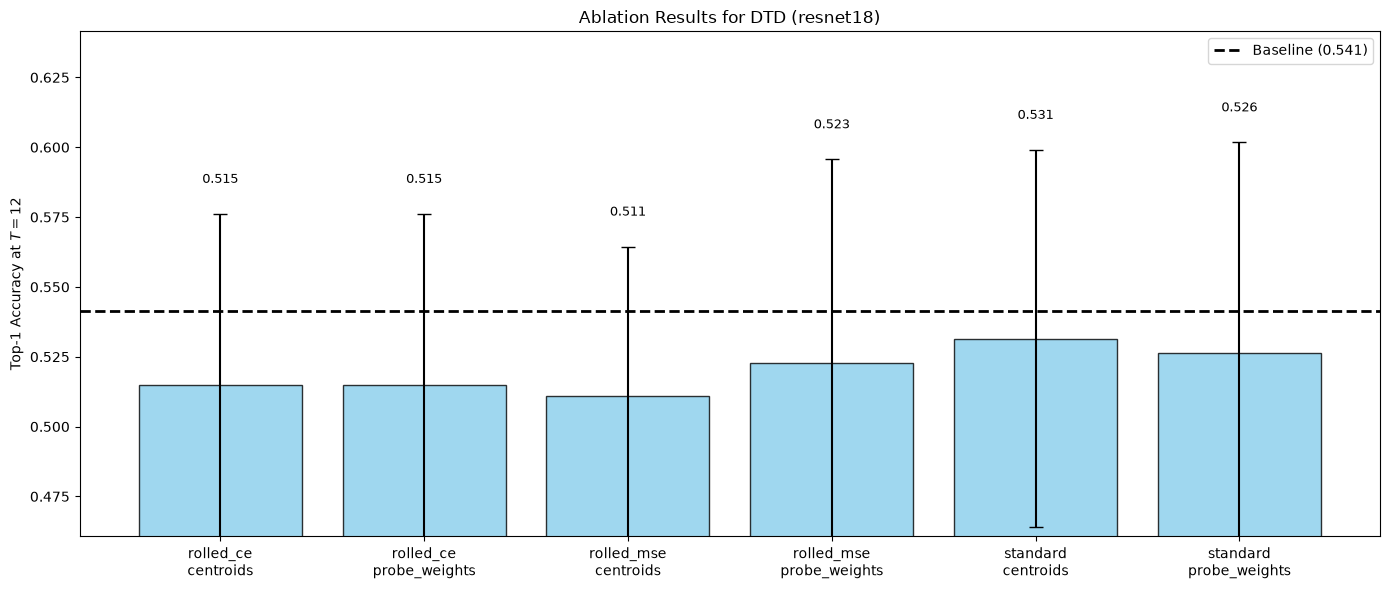

In [5]:

runs = [r for r in fm_results.values() if r['encoder'] == 'resnet18' and r['dataset'] == 'dtd']
if runs:
    plt.figure(figsize=(14, 6))
    
    baselines = [r['baseline_accuracy'] for r in runs]
    avg_base = np.mean(baselines)
    plt.axhline(avg_base, color='black', linestyle='--', linewidth=2, label=f'Baseline ({avg_base:.3f})')
    
    config_accs = defaultdict(list)
    for r in runs:
        conf = f"{r['objective']}\n{r['target_type']}"
        config_accs[conf].append(r['accuracy_by_steps'].get(12, 0))
        
    labels = []
    means = []
    stds = []
    for conf in sorted(config_accs.keys()):
        labels.append(conf)
        means.append(np.mean(config_accs[conf]))
        stds.append(np.std(config_accs[conf]))
        
    x = np.arange(len(labels))
    bars = plt.bar(x, means, yerr=stds, capsize=5, color='skyblue', edgecolor='black', alpha=0.8)
    plt.xticks(x, labels, rotation=0, ha='center')
    plt.ylabel('Top-1 Accuracy at $T=12$')
    plt.title(f'Ablation Results for DTD (resnet18)')
    
    for j, bar in enumerate(bars):
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + stds[j] + 0.01, f"{yval:.3f}", ha='center', va='bottom', fontsize=9)
        
    min_y = max(0, min([avg_base] + means) - 0.05)
    max_y = min(1.0, max([avg_base] + means) + 0.1)
    plt.ylim(min_y, max_y)
        
    plt.legend()
    plt.tight_layout()
    plt.show()


### 4.2 Ablation Results: `AIRCRAFT` (resnet18)

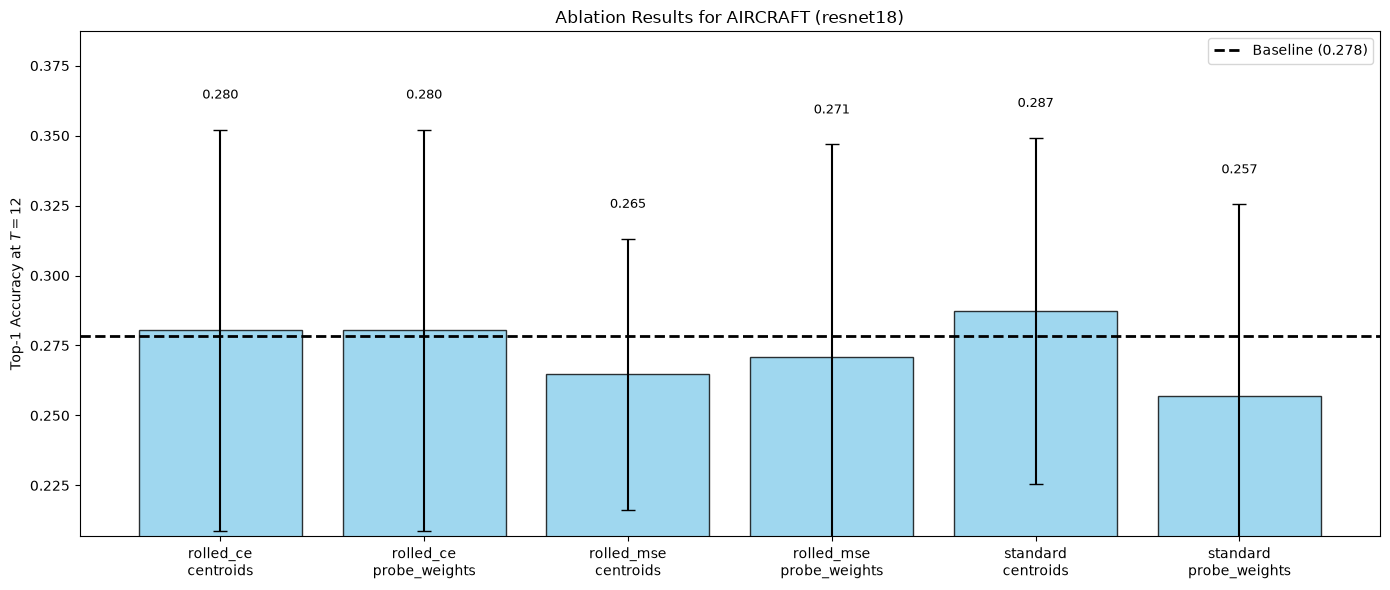

In [6]:

runs = [r for r in fm_results.values() if r['encoder'] == 'resnet18' and r['dataset'] == 'aircraft']
if runs:
    plt.figure(figsize=(14, 6))
    
    baselines = [r['baseline_accuracy'] for r in runs]
    avg_base = np.mean(baselines)
    plt.axhline(avg_base, color='black', linestyle='--', linewidth=2, label=f'Baseline ({avg_base:.3f})')
    
    config_accs = defaultdict(list)
    for r in runs:
        conf = f"{r['objective']}\n{r['target_type']}"
        config_accs[conf].append(r['accuracy_by_steps'].get(12, 0))
        
    labels = []
    means = []
    stds = []
    for conf in sorted(config_accs.keys()):
        labels.append(conf)
        means.append(np.mean(config_accs[conf]))
        stds.append(np.std(config_accs[conf]))
        
    x = np.arange(len(labels))
    bars = plt.bar(x, means, yerr=stds, capsize=5, color='skyblue', edgecolor='black', alpha=0.8)
    plt.xticks(x, labels, rotation=0, ha='center')
    plt.ylabel('Top-1 Accuracy at $T=12$')
    plt.title(f'Ablation Results for AIRCRAFT (resnet18)')
    
    for j, bar in enumerate(bars):
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + stds[j] + 0.01, f"{yval:.3f}", ha='center', va='bottom', fontsize=9)
        
    min_y = max(0, min([avg_base] + means) - 0.05)
    max_y = min(1.0, max([avg_base] + means) + 0.1)
    plt.ylim(min_y, max_y)
        
    plt.legend()
    plt.tight_layout()
    plt.show()


### 4.3 Ablation Results: `DTD` (dinov2_vits14)

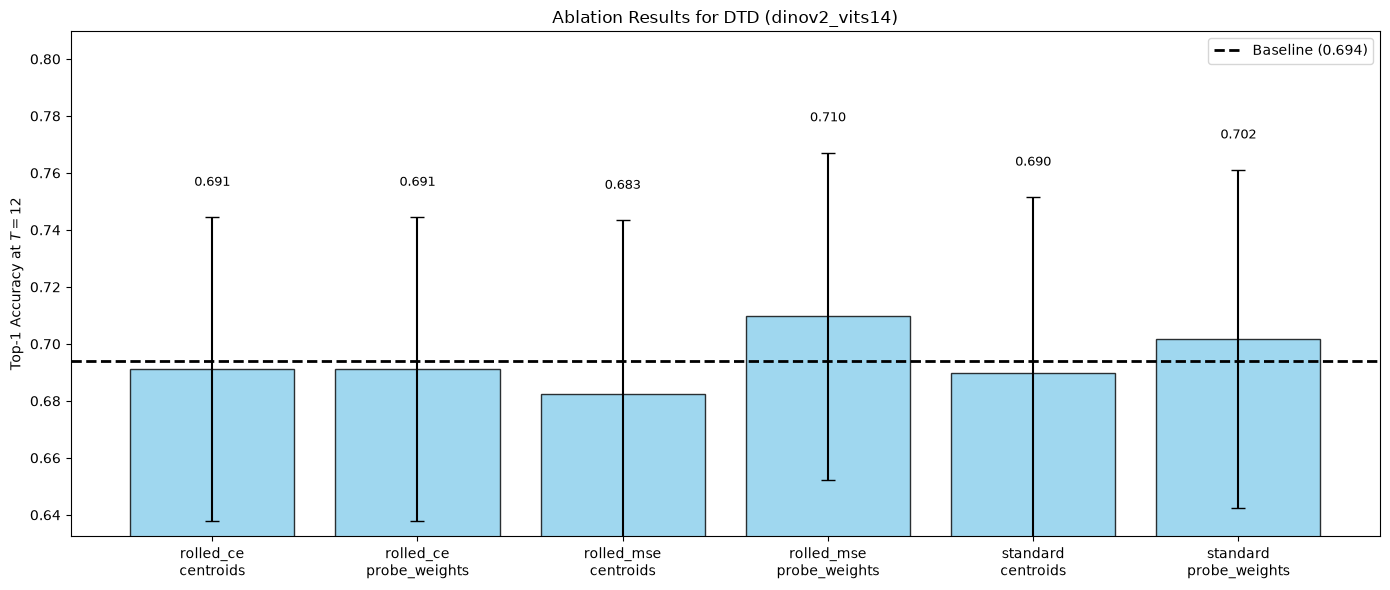

In [7]:

runs = [r for r in fm_results.values() if r['encoder'] == 'dinov2_vits14' and r['dataset'] == 'dtd']
if runs:
    plt.figure(figsize=(14, 6))
    
    baselines = [r['baseline_accuracy'] for r in runs]
    avg_base = np.mean(baselines)
    plt.axhline(avg_base, color='black', linestyle='--', linewidth=2, label=f'Baseline ({avg_base:.3f})')
    
    config_accs = defaultdict(list)
    for r in runs:
        conf = f"{r['objective']}\n{r['target_type']}"
        config_accs[conf].append(r['accuracy_by_steps'].get(12, 0))
        
    labels = []
    means = []
    stds = []
    for conf in sorted(config_accs.keys()):
        labels.append(conf)
        means.append(np.mean(config_accs[conf]))
        stds.append(np.std(config_accs[conf]))
        
    x = np.arange(len(labels))
    bars = plt.bar(x, means, yerr=stds, capsize=5, color='skyblue', edgecolor='black', alpha=0.8)
    plt.xticks(x, labels, rotation=0, ha='center')
    plt.ylabel('Top-1 Accuracy at $T=12$')
    plt.title(f'Ablation Results for DTD (dinov2_vits14)')
    
    for j, bar in enumerate(bars):
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + stds[j] + 0.01, f"{yval:.3f}", ha='center', va='bottom', fontsize=9)
        
    min_y = max(0, min([avg_base] + means) - 0.05)
    max_y = min(1.0, max([avg_base] + means) + 0.1)
    plt.ylim(min_y, max_y)
        
    plt.legend()
    plt.tight_layout()
    plt.show()


## 5. Visualizing the Learned Dynamics
To understand *why* certain targets or objectives perform better, we will visualize their learned fields. 
We fix `K=10` and `Seed=0`, and iterate over the datasets/encoders.


### 5.1 Objective: `STANDARD` | Dataset: `DTD` (resnet18)


=== CONFIGURATION (Noise 1.0): Objective = STANDARD     | Target = CENTROIDS       | Dataset = DTD (resnet18) ===



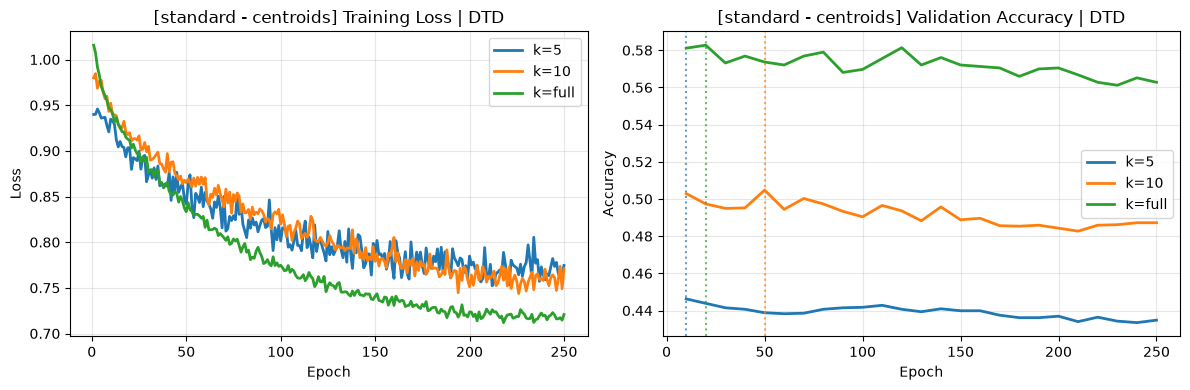


> Plotting 2D Vector Field (k=full)...


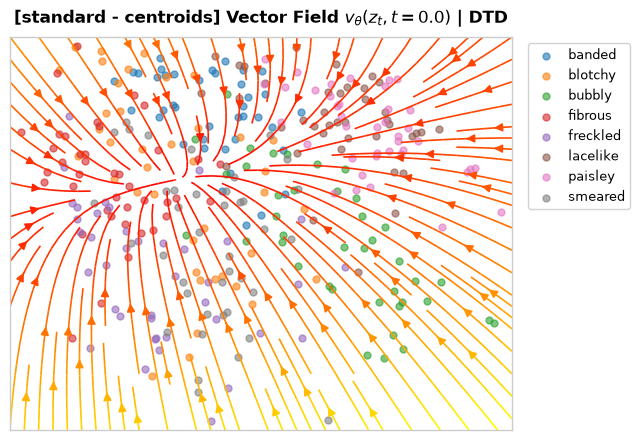

> Plotting Trajectories (k=full, T=4)...


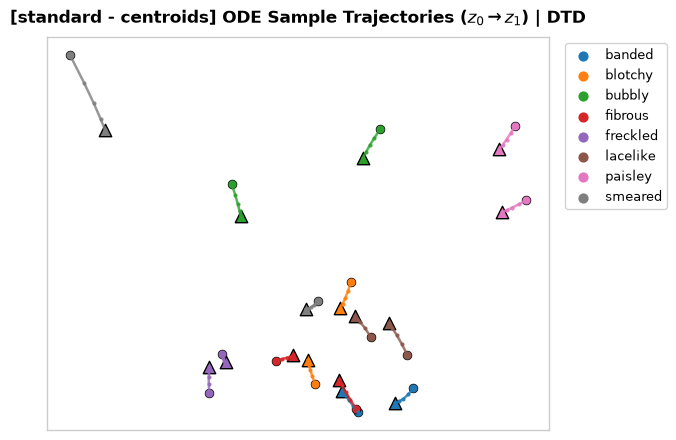

> Plotting Trajectories (k=full, T=12)...


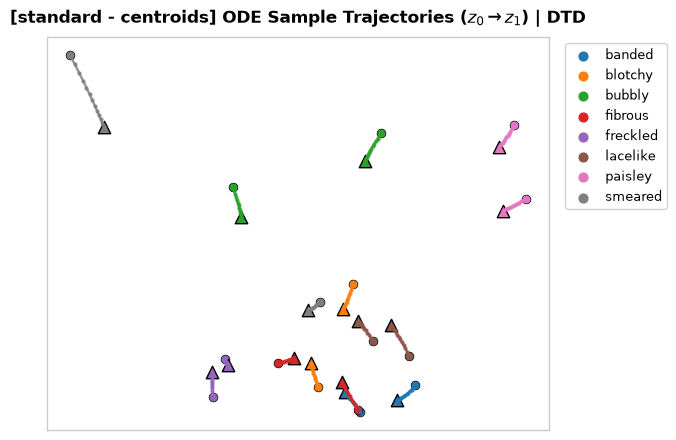


=== CONFIGURATION (Noise 1.0): Objective = STANDARD     | Target = PROBE_WEIGHTS   | Dataset = DTD (resnet18) ===



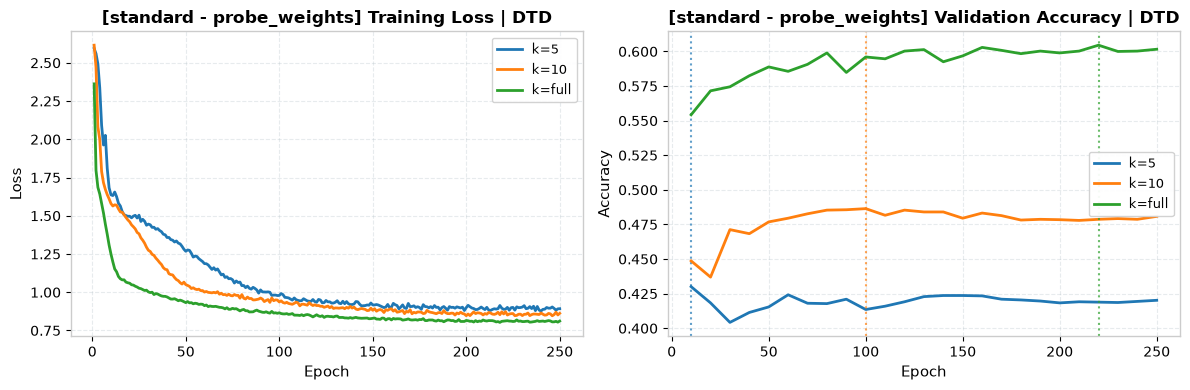


> Plotting 2D Vector Field (k=full)...


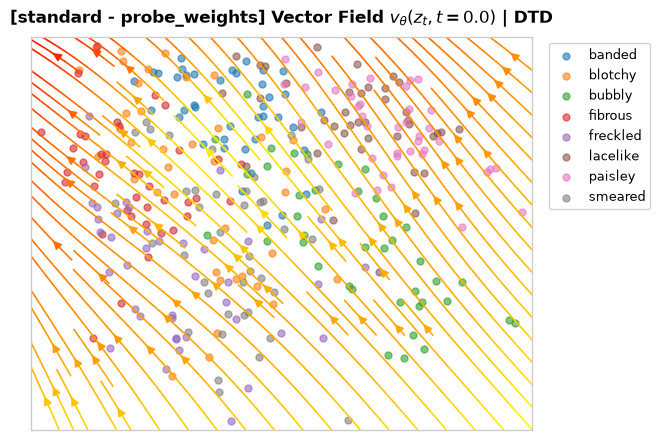

> Plotting Trajectories (k=full, T=4)...


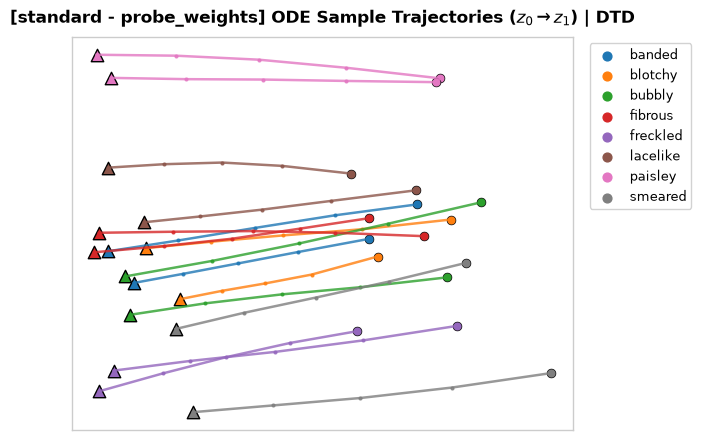

> Plotting Trajectories (k=full, T=12)...


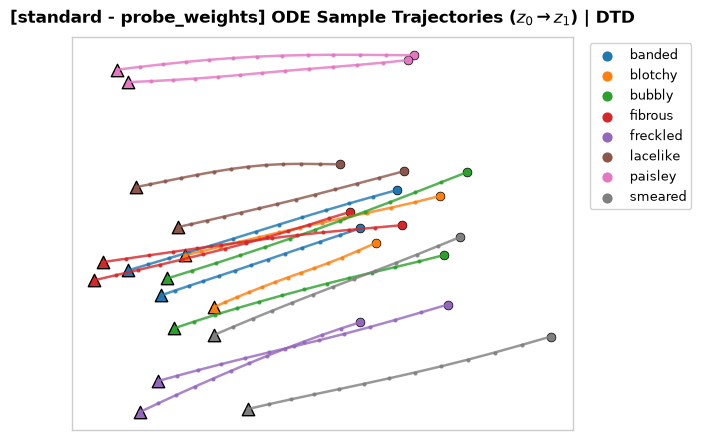

In [8]:
obj = "standard"
target_seed = 0
target_encoder = "resnet18"
target_dataset = "dtd"

from src.fmlayer.features.cache import load_split
from src.fmlayer.viz.flow_viz import plot_flow_vector_field_2d, plot_flow_trajectories_2d
from src.fmlayer.train.train_fm import TARGET_TYPES
from src.fmlayer.data.datasets import build_dataset, get_class_names

val_features, val_labels, _ = load_split(target_encoder, target_dataset, "val", FEATURE_ROOT)
val_dataset = build_dataset(target_dataset, "val")
class_names = get_class_names(val_dataset)

for tgt in TARGET_TYPES:
    # Gather history for all K
    histories = {}
    best_epochs = {}
    fm_layer_full = None
    
    for k in [5, 10, "full"]:
        for key, r in fm_results.items():
            if r["encoder"] == target_encoder and r["dataset"] == target_dataset and str(r["k"]) == str(k) and r["seed"] == target_seed and r["objective"] == obj and r["target_type"] == tgt and r.get('target_noise_scale', 0.0) == 1.0:
                histories[k] = r["history"]
                best_epochs[k] = r["best_epoch"]
                if str(k) == "full":
                    fm_layer_full = r["fm_layer"]
                break
    
    if not histories:
        continue
        
    print(f"\n{'='*90}")
    print(f"=== CONFIGURATION (Noise 1.0): Objective = {obj.upper():<12} | Target = {tgt.upper():<15} | Dataset = {target_dataset.upper()} ({target_encoder}) ===")
    print(f"{'='*90}\n")
    
    # 1. Plot Loss
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    colors = {5: '#1f77b4', 10: '#ff7f0e', "full": '#2ca02c'}
    
    for k, history in histories.items():
        epochs = [entry["epoch"] for entry in history]
        train_loss = [entry["train_loss"] for entry in history]
        
        val_epochs = [entry["epoch"] for entry in history if "val_accuracy" in entry]
        val_acc = [entry["val_accuracy"] for entry in history if "val_accuracy" in entry]

        ax1.plot(epochs, train_loss, color=colors[k], linewidth=2, label=f'k={k}')
        
        if len(val_epochs) > 0:
            ax2.plot(val_epochs, val_acc, color=colors[k], linewidth=2, label=f'k={k}')
        if k in best_epochs and best_epochs[k] is not None:
            ax2.axvline(best_epochs[k], color=colors[k], linestyle=':', alpha=0.7)

    ax1.set_title(f"[{obj} - {tgt}] Training Loss | {target_dataset.upper()}")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.grid(alpha=0.3)
    ax1.legend()

    ax2.set_title(f"[{obj} - {tgt}] Validation Accuracy | {target_dataset.upper()}")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.grid(alpha=0.3)
    ax2.legend()
    plt.tight_layout()
    plt.show()
    
    if fm_layer_full is not None:
        metadata = {"dataset": target_dataset, "class_names": class_names, "objective": obj, "target_type": tgt}
        
        # 2. Vector Field
        print("\n> Plotting 2D Vector Field (k=full)...")
        plot_flow_vector_field_2d(
            fm_layer=fm_layer_full,
            features=val_features,
            labels=val_labels,
            metadata=metadata,
            t=0.0
        )
        
        # 3. Flow Trajectories
        print("> Plotting Trajectories (k=full, T=4)...")
        plot_flow_trajectories_2d(
            fm_layer=fm_layer_full,
            features=val_features,
            labels=val_labels,
            metadata=metadata,
            num_steps=4
        )
        
        print("> Plotting Trajectories (k=full, T=12)...")
        plot_flow_trajectories_2d(
            fm_layer=fm_layer_full,
            features=val_features,
            labels=val_labels,
            metadata=metadata,
            num_steps=12
        )


### 5.2 Objective: `STANDARD` | Dataset: `AIRCRAFT` (resnet18)


=== CONFIGURATION (Noise 1.0): Objective = STANDARD     | Target = CENTROIDS       | Dataset = AIRCRAFT (resnet18) ===



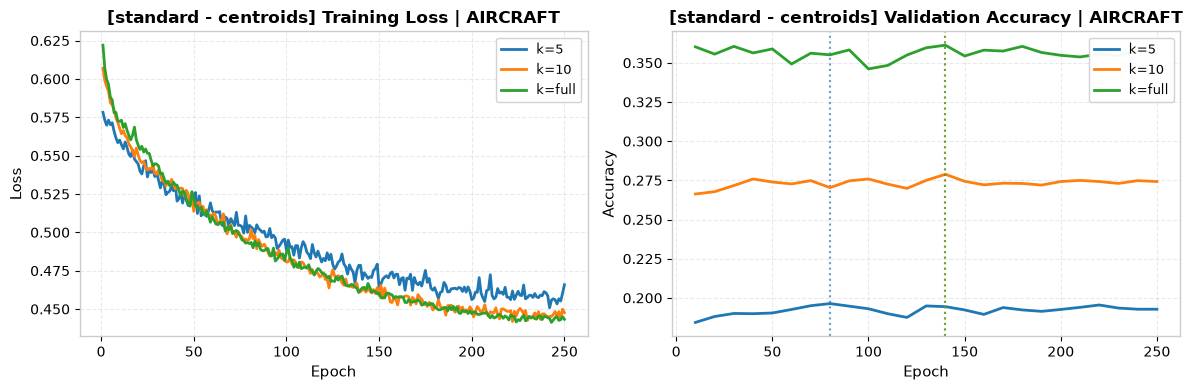


> Plotting 2D Vector Field (k=full)...


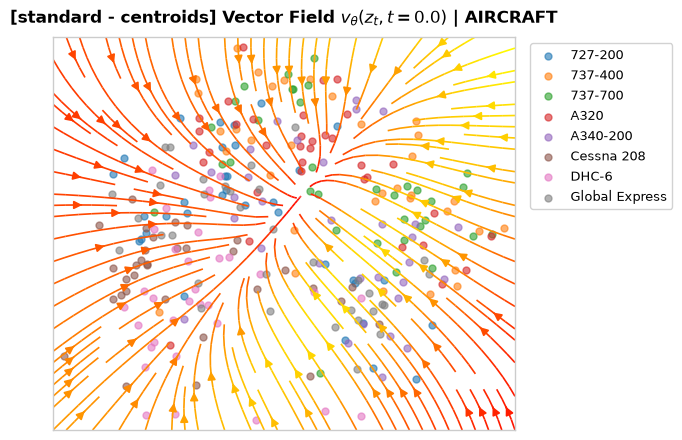

> Plotting Trajectories (k=full, T=4)...


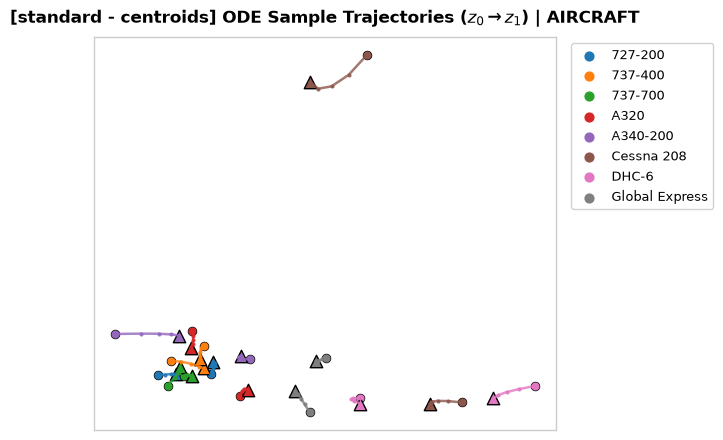

> Plotting Trajectories (k=full, T=12)...


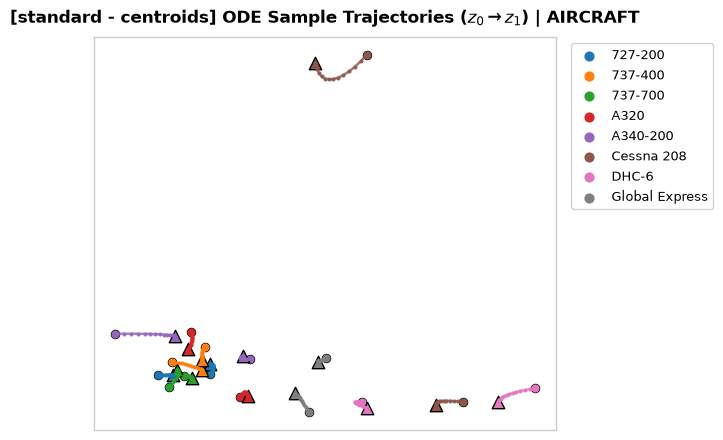


=== CONFIGURATION (Noise 1.0): Objective = STANDARD     | Target = PROBE_WEIGHTS   | Dataset = AIRCRAFT (resnet18) ===



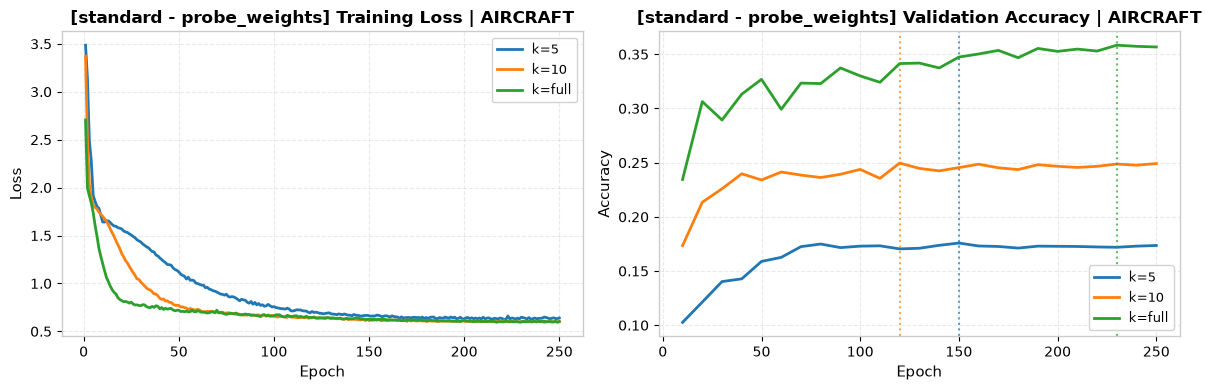


> Plotting 2D Vector Field (k=full)...


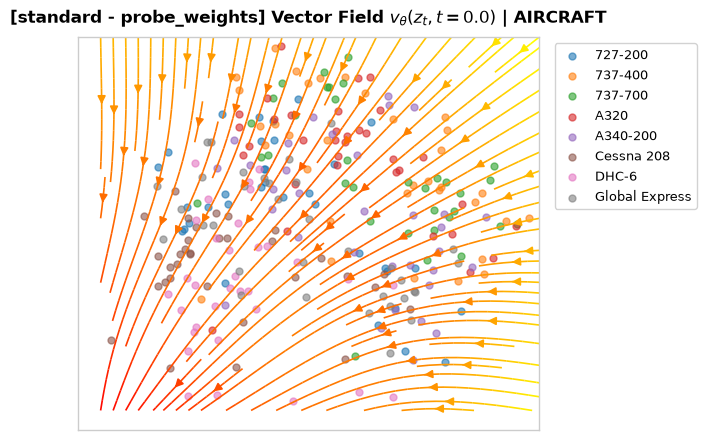

> Plotting Trajectories (k=full, T=4)...


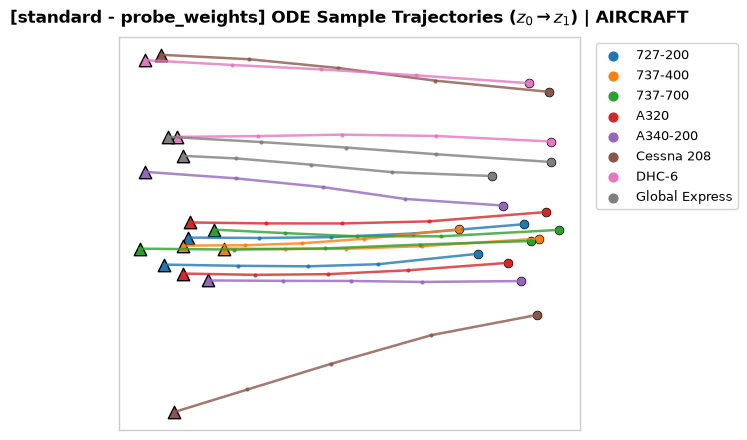

> Plotting Trajectories (k=full, T=12)...


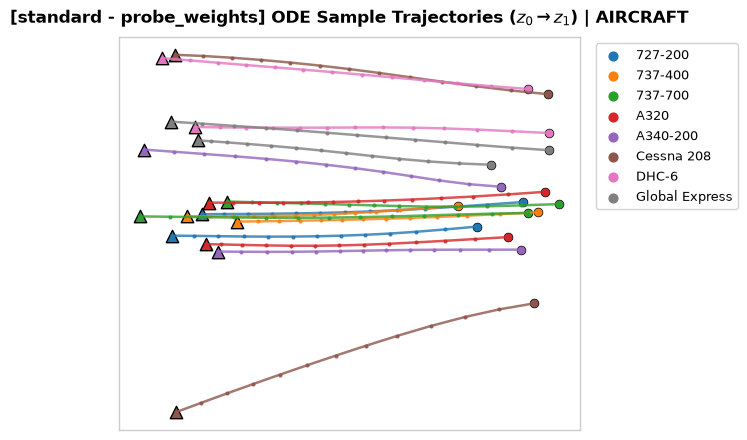

In [9]:
obj = "standard"
target_seed = 0
target_encoder = "resnet18"
target_dataset = "aircraft"

from src.fmlayer.features.cache import load_split
from src.fmlayer.viz.flow_viz import plot_flow_vector_field_2d, plot_flow_trajectories_2d
from src.fmlayer.train.train_fm import TARGET_TYPES
from src.fmlayer.data.datasets import build_dataset, get_class_names

val_features, val_labels, _ = load_split(target_encoder, target_dataset, "val", FEATURE_ROOT)
val_dataset = build_dataset(target_dataset, "val")
class_names = get_class_names(val_dataset)

for tgt in TARGET_TYPES:
    # Gather history for all K
    histories = {}
    best_epochs = {}
    fm_layer_full = None
    
    for k in [5, 10, "full"]:
        for key, r in fm_results.items():
            if r["encoder"] == target_encoder and r["dataset"] == target_dataset and str(r["k"]) == str(k) and r["seed"] == target_seed and r["objective"] == obj and r["target_type"] == tgt and r.get('target_noise_scale', 0.0) == 1.0:
                histories[k] = r["history"]
                best_epochs[k] = r["best_epoch"]
                if str(k) == "full":
                    fm_layer_full = r["fm_layer"]
                break
    
    if not histories:
        continue
        
    print(f"\n{'='*90}")
    print(f"=== CONFIGURATION (Noise 1.0): Objective = {obj.upper():<12} | Target = {tgt.upper():<15} | Dataset = {target_dataset.upper()} ({target_encoder}) ===")
    print(f"{'='*90}\n")
    
    # 1. Plot Loss
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    colors = {5: '#1f77b4', 10: '#ff7f0e', "full": '#2ca02c'}
    
    for k, history in histories.items():
        epochs = [entry["epoch"] for entry in history]
        train_loss = [entry["train_loss"] for entry in history]
        
        val_epochs = [entry["epoch"] for entry in history if "val_accuracy" in entry]
        val_acc = [entry["val_accuracy"] for entry in history if "val_accuracy" in entry]

        ax1.plot(epochs, train_loss, color=colors[k], linewidth=2, label=f'k={k}')
        
        if len(val_epochs) > 0:
            ax2.plot(val_epochs, val_acc, color=colors[k], linewidth=2, label=f'k={k}')
        if k in best_epochs and best_epochs[k] is not None:
            ax2.axvline(best_epochs[k], color=colors[k], linestyle=':', alpha=0.7)

    ax1.set_title(f"[{obj} - {tgt}] Training Loss | {target_dataset.upper()}")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.grid(alpha=0.3)
    ax1.legend()

    ax2.set_title(f"[{obj} - {tgt}] Validation Accuracy | {target_dataset.upper()}")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.grid(alpha=0.3)
    ax2.legend()
    plt.tight_layout()
    plt.show()
    
    if fm_layer_full is not None:
        metadata = {"dataset": target_dataset, "class_names": class_names, "objective": obj, "target_type": tgt}
        
        # 2. Vector Field
        print("\n> Plotting 2D Vector Field (k=full)...")
        plot_flow_vector_field_2d(
            fm_layer=fm_layer_full,
            features=val_features,
            labels=val_labels,
            metadata=metadata,
            t=0.0
        )
        
        # 3. Flow Trajectories
        print("> Plotting Trajectories (k=full, T=4)...")
        plot_flow_trajectories_2d(
            fm_layer=fm_layer_full,
            features=val_features,
            labels=val_labels,
            metadata=metadata,
            num_steps=4
        )
        
        print("> Plotting Trajectories (k=full, T=12)...")
        plot_flow_trajectories_2d(
            fm_layer=fm_layer_full,
            features=val_features,
            labels=val_labels,
            metadata=metadata,
            num_steps=12
        )


### 5.3 Objective: `STANDARD` | Dataset: `DTD` (dinov2_vits14)


=== CONFIGURATION (Noise 1.0): Objective = STANDARD     | Target = CENTROIDS       | Dataset = DTD (dinov2_vits14) ===



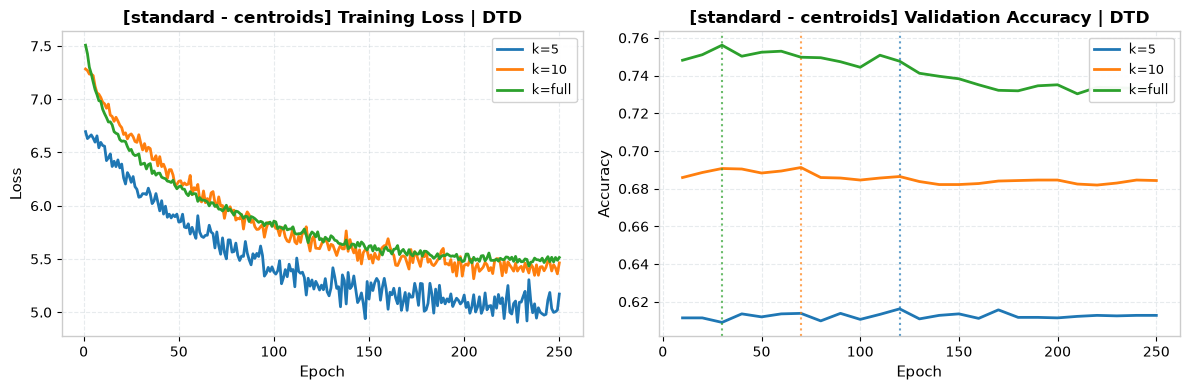


> Plotting 2D Vector Field (k=full)...


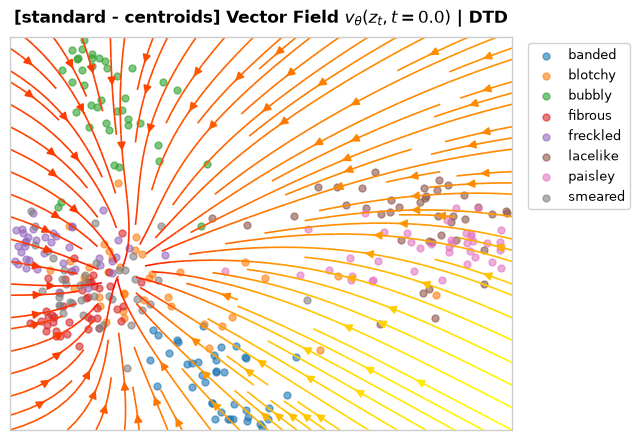

> Plotting Trajectories (k=full, T=4)...


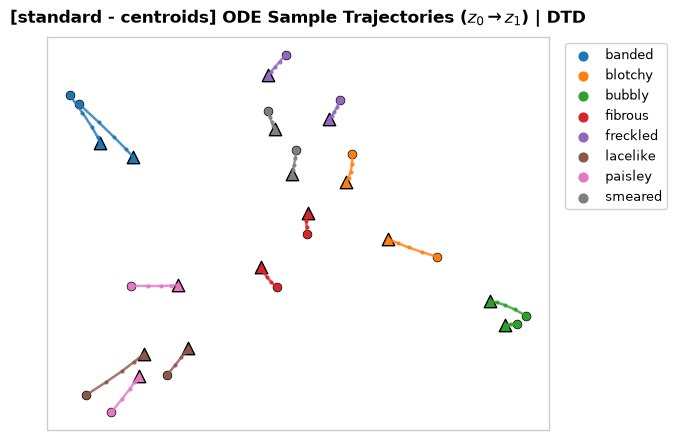

> Plotting Trajectories (k=full, T=12)...


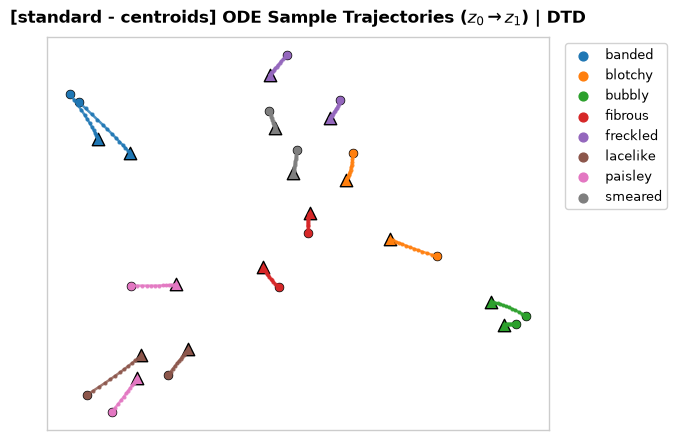


=== CONFIGURATION (Noise 1.0): Objective = STANDARD     | Target = PROBE_WEIGHTS   | Dataset = DTD (dinov2_vits14) ===



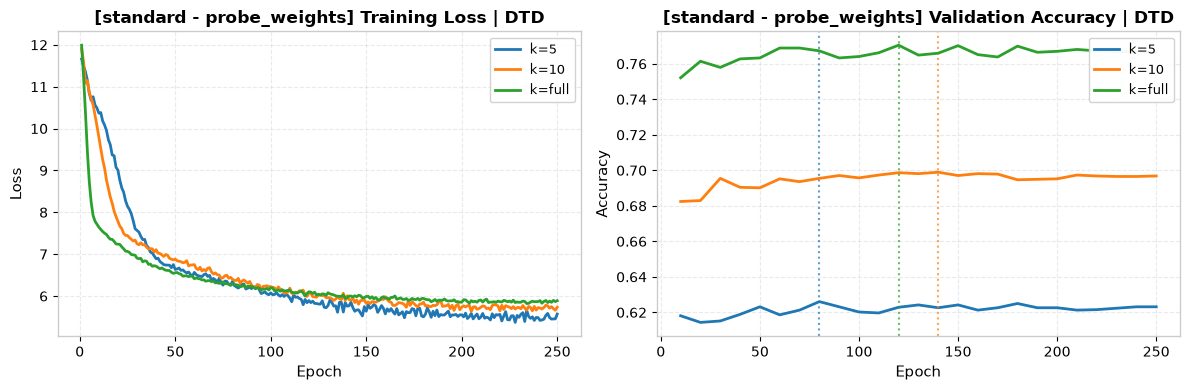


> Plotting 2D Vector Field (k=full)...


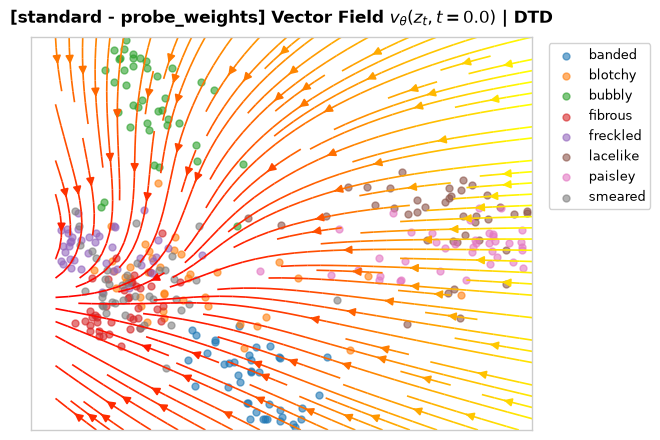

> Plotting Trajectories (k=full, T=4)...


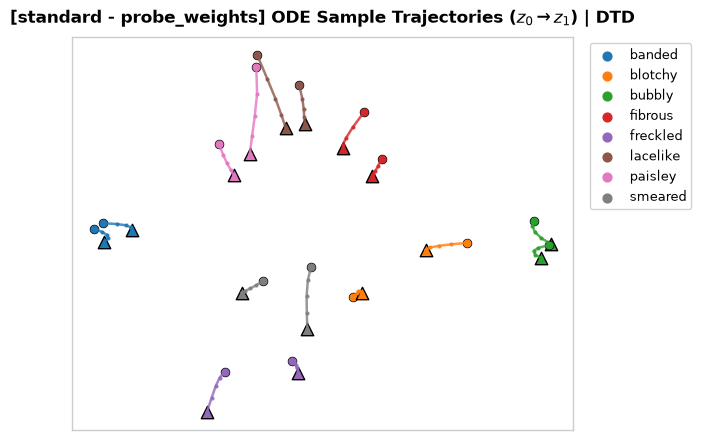

> Plotting Trajectories (k=full, T=12)...


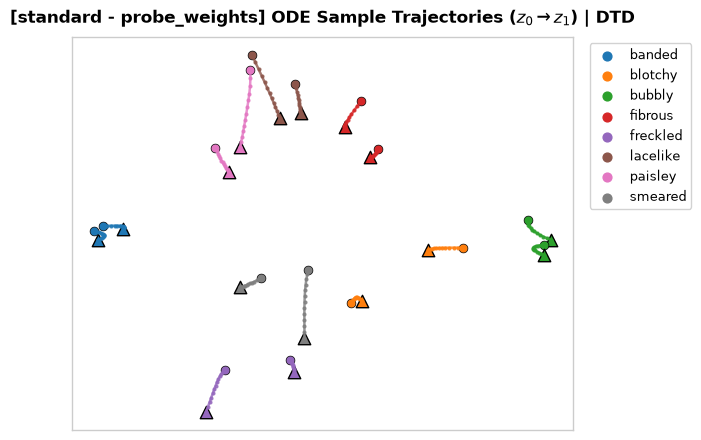

In [10]:
obj = "standard"
target_seed = 0
target_encoder = "dinov2_vits14"
target_dataset = "dtd"

from src.fmlayer.features.cache import load_split
from src.fmlayer.viz.flow_viz import plot_flow_vector_field_2d, plot_flow_trajectories_2d
from src.fmlayer.train.train_fm import TARGET_TYPES
from src.fmlayer.data.datasets import build_dataset, get_class_names

val_features, val_labels, _ = load_split(target_encoder, target_dataset, "val", FEATURE_ROOT)
val_dataset = build_dataset(target_dataset, "val")
class_names = get_class_names(val_dataset)

for tgt in TARGET_TYPES:
    # Gather history for all K
    histories = {}
    best_epochs = {}
    fm_layer_full = None
    
    for k in [5, 10, "full"]:
        for key, r in fm_results.items():
            if r["encoder"] == target_encoder and r["dataset"] == target_dataset and str(r["k"]) == str(k) and r["seed"] == target_seed and r["objective"] == obj and r["target_type"] == tgt and r.get('target_noise_scale', 0.0) == 1.0:
                histories[k] = r["history"]
                best_epochs[k] = r["best_epoch"]
                if str(k) == "full":
                    fm_layer_full = r["fm_layer"]
                break
    
    if not histories:
        continue
        
    print(f"\n{'='*90}")
    print(f"=== CONFIGURATION (Noise 1.0): Objective = {obj.upper():<12} | Target = {tgt.upper():<15} | Dataset = {target_dataset.upper()} ({target_encoder}) ===")
    print(f"{'='*90}\n")
    
    # 1. Plot Loss
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    colors = {5: '#1f77b4', 10: '#ff7f0e', "full": '#2ca02c'}
    
    for k, history in histories.items():
        epochs = [entry["epoch"] for entry in history]
        train_loss = [entry["train_loss"] for entry in history]
        
        val_epochs = [entry["epoch"] for entry in history if "val_accuracy" in entry]
        val_acc = [entry["val_accuracy"] for entry in history if "val_accuracy" in entry]

        ax1.plot(epochs, train_loss, color=colors[k], linewidth=2, label=f'k={k}')
        
        if len(val_epochs) > 0:
            ax2.plot(val_epochs, val_acc, color=colors[k], linewidth=2, label=f'k={k}')
        if k in best_epochs and best_epochs[k] is not None:
            ax2.axvline(best_epochs[k], color=colors[k], linestyle=':', alpha=0.7)

    ax1.set_title(f"[{obj} - {tgt}] Training Loss | {target_dataset.upper()}")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.grid(alpha=0.3)
    ax1.legend()

    ax2.set_title(f"[{obj} - {tgt}] Validation Accuracy | {target_dataset.upper()}")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.grid(alpha=0.3)
    ax2.legend()
    plt.tight_layout()
    plt.show()
    
    if fm_layer_full is not None:
        metadata = {"dataset": target_dataset, "class_names": class_names, "objective": obj, "target_type": tgt}
        
        # 2. Vector Field
        print("\n> Plotting 2D Vector Field (k=full)...")
        plot_flow_vector_field_2d(
            fm_layer=fm_layer_full,
            features=val_features,
            labels=val_labels,
            metadata=metadata,
            t=0.0
        )
        
        # 3. Flow Trajectories
        print("> Plotting Trajectories (k=full, T=4)...")
        plot_flow_trajectories_2d(
            fm_layer=fm_layer_full,
            features=val_features,
            labels=val_labels,
            metadata=metadata,
            num_steps=4
        )
        
        print("> Plotting Trajectories (k=full, T=12)...")
        plot_flow_trajectories_2d(
            fm_layer=fm_layer_full,
            features=val_features,
            labels=val_labels,
            metadata=metadata,
            num_steps=12
        )


### 5.4 Objective: `ROLLED_MSE` | Dataset: `DTD` (resnet18)


=== CONFIGURATION (Noise 1.0): Objective = ROLLED_MSE   | Target = CENTROIDS       | Dataset = DTD (resnet18) ===



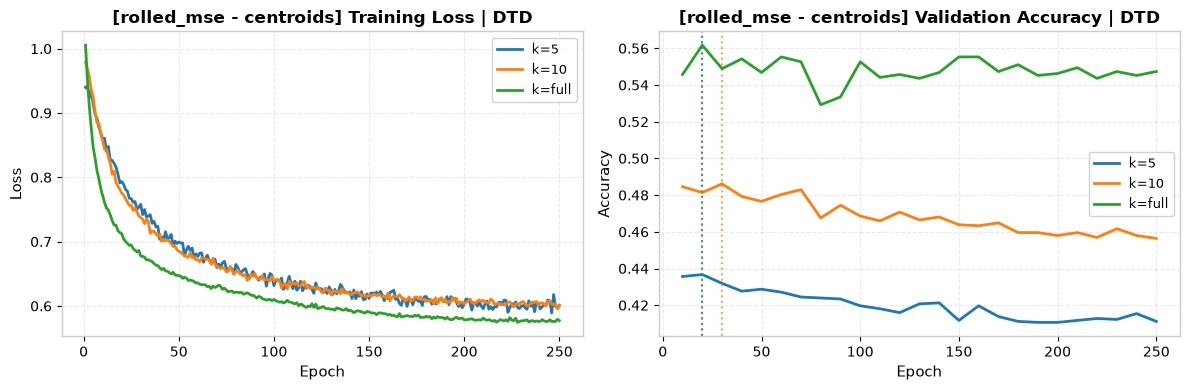


> Plotting 2D Vector Field (k=full)...


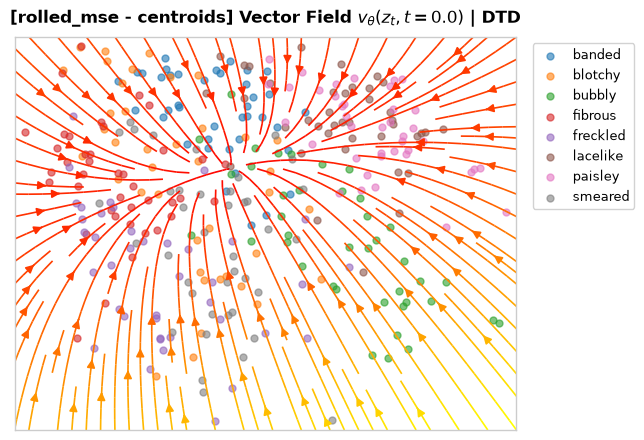

> Plotting Trajectories (k=full, T=4)...


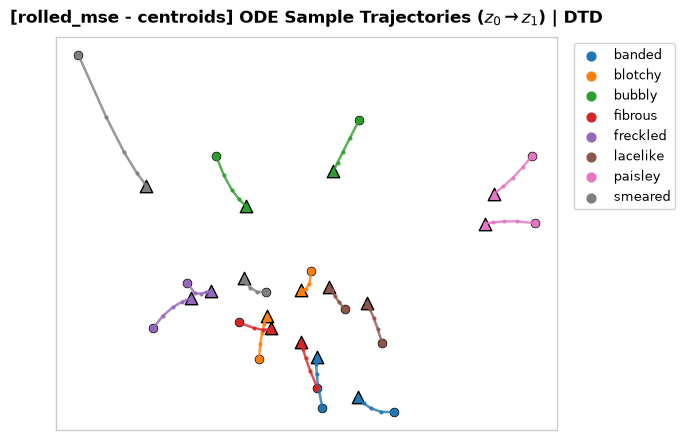

> Plotting Trajectories (k=full, T=12)...


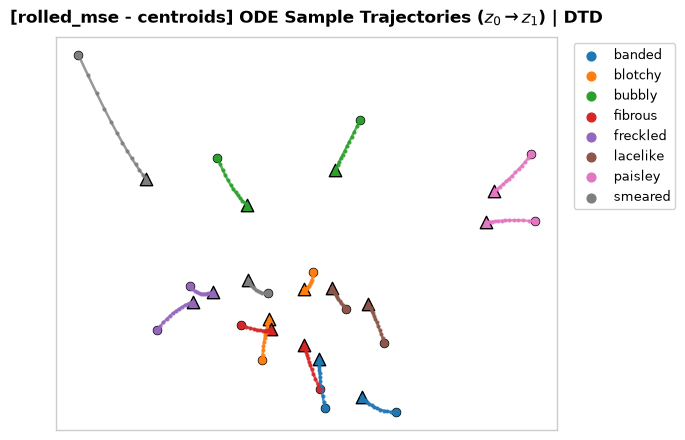


=== CONFIGURATION (Noise 1.0): Objective = ROLLED_MSE   | Target = PROBE_WEIGHTS   | Dataset = DTD (resnet18) ===



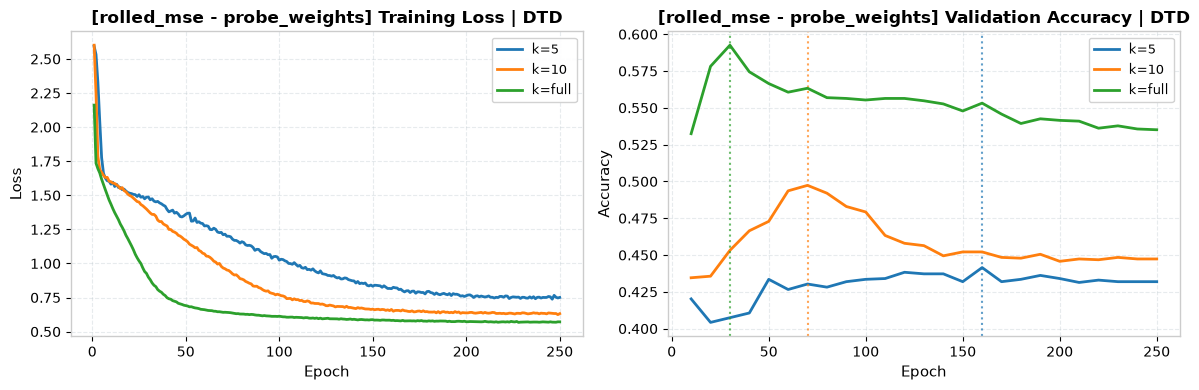


> Plotting 2D Vector Field (k=full)...


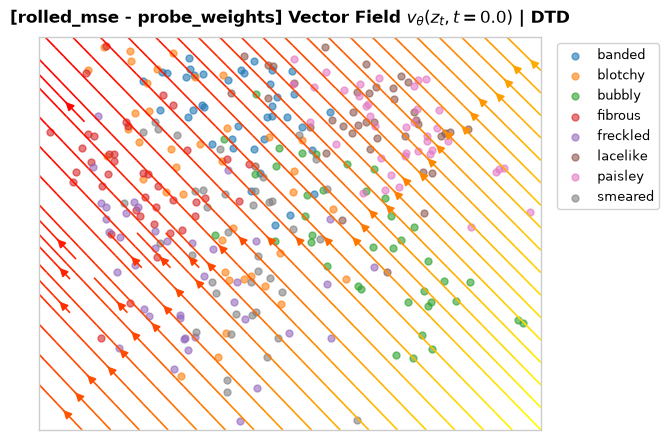

> Plotting Trajectories (k=full, T=4)...


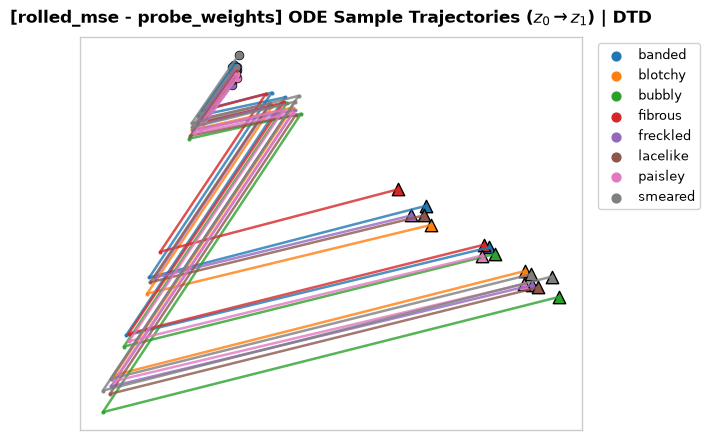

> Plotting Trajectories (k=full, T=12)...


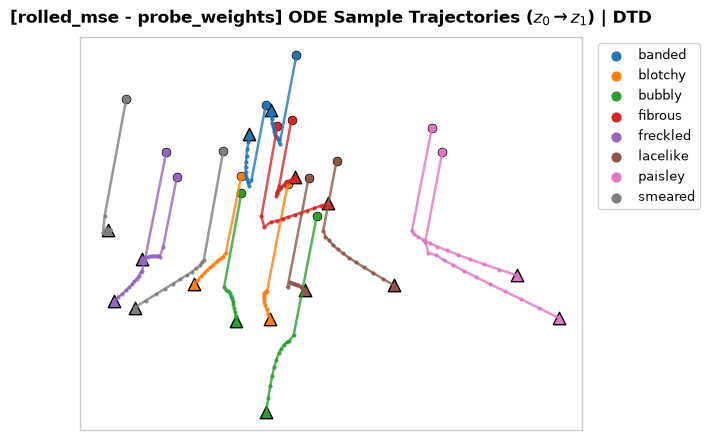

In [11]:
obj = "rolled_mse"
target_seed = 0
target_encoder = "resnet18"
target_dataset = "dtd"

from src.fmlayer.features.cache import load_split
from src.fmlayer.viz.flow_viz import plot_flow_vector_field_2d, plot_flow_trajectories_2d
from src.fmlayer.train.train_fm import TARGET_TYPES
from src.fmlayer.data.datasets import build_dataset, get_class_names

val_features, val_labels, _ = load_split(target_encoder, target_dataset, "val", FEATURE_ROOT)
val_dataset = build_dataset(target_dataset, "val")
class_names = get_class_names(val_dataset)

for tgt in TARGET_TYPES:
    # Gather history for all K
    histories = {}
    best_epochs = {}
    fm_layer_full = None
    
    for k in [5, 10, "full"]:
        for key, r in fm_results.items():
            if r["encoder"] == target_encoder and r["dataset"] == target_dataset and str(r["k"]) == str(k) and r["seed"] == target_seed and r["objective"] == obj and r["target_type"] == tgt and r.get('target_noise_scale', 0.0) == 1.0:
                histories[k] = r["history"]
                best_epochs[k] = r["best_epoch"]
                if str(k) == "full":
                    fm_layer_full = r["fm_layer"]
                break
    
    if not histories:
        continue
        
    print(f"\n{'='*90}")
    print(f"=== CONFIGURATION (Noise 1.0): Objective = {obj.upper():<12} | Target = {tgt.upper():<15} | Dataset = {target_dataset.upper()} ({target_encoder}) ===")
    print(f"{'='*90}\n")
    
    # 1. Plot Loss
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    colors = {5: '#1f77b4', 10: '#ff7f0e', "full": '#2ca02c'}
    
    for k, history in histories.items():
        epochs = [entry["epoch"] for entry in history]
        train_loss = [entry["train_loss"] for entry in history]
        
        val_epochs = [entry["epoch"] for entry in history if "val_accuracy" in entry]
        val_acc = [entry["val_accuracy"] for entry in history if "val_accuracy" in entry]

        ax1.plot(epochs, train_loss, color=colors[k], linewidth=2, label=f'k={k}')
        
        if len(val_epochs) > 0:
            ax2.plot(val_epochs, val_acc, color=colors[k], linewidth=2, label=f'k={k}')
        if k in best_epochs and best_epochs[k] is not None:
            ax2.axvline(best_epochs[k], color=colors[k], linestyle=':', alpha=0.7)

    ax1.set_title(f"[{obj} - {tgt}] Training Loss | {target_dataset.upper()}")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.grid(alpha=0.3)
    ax1.legend()

    ax2.set_title(f"[{obj} - {tgt}] Validation Accuracy | {target_dataset.upper()}")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.grid(alpha=0.3)
    ax2.legend()
    plt.tight_layout()
    plt.show()
    
    if fm_layer_full is not None:
        metadata = {"dataset": target_dataset, "class_names": class_names, "objective": obj, "target_type": tgt}
        
        # 2. Vector Field
        print("\n> Plotting 2D Vector Field (k=full)...")
        plot_flow_vector_field_2d(
            fm_layer=fm_layer_full,
            features=val_features,
            labels=val_labels,
            metadata=metadata,
            t=0.0
        )
        
        # 3. Flow Trajectories
        print("> Plotting Trajectories (k=full, T=4)...")
        plot_flow_trajectories_2d(
            fm_layer=fm_layer_full,
            features=val_features,
            labels=val_labels,
            metadata=metadata,
            num_steps=4
        )
        
        print("> Plotting Trajectories (k=full, T=12)...")
        plot_flow_trajectories_2d(
            fm_layer=fm_layer_full,
            features=val_features,
            labels=val_labels,
            metadata=metadata,
            num_steps=12
        )


### 5.5 Objective: `ROLLED_MSE` | Dataset: `AIRCRAFT` (resnet18)


=== CONFIGURATION (Noise 1.0): Objective = ROLLED_MSE   | Target = CENTROIDS       | Dataset = AIRCRAFT (resnet18) ===



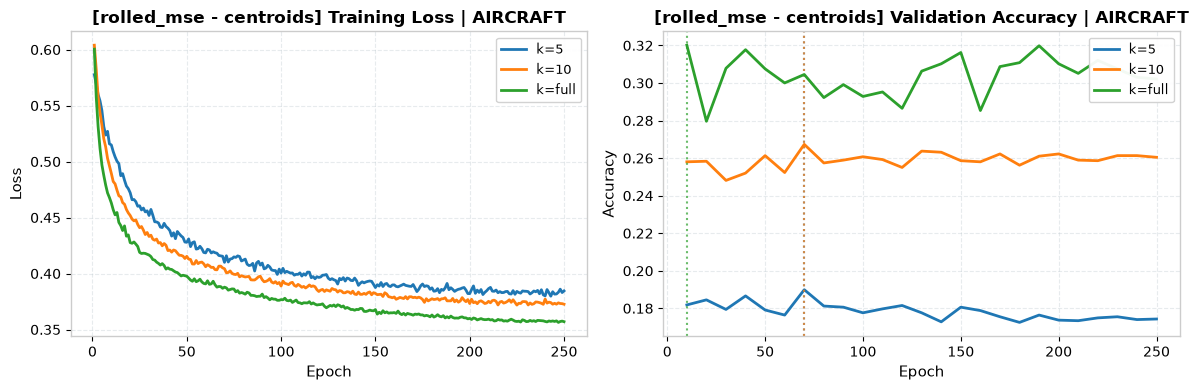


> Plotting 2D Vector Field (k=full)...


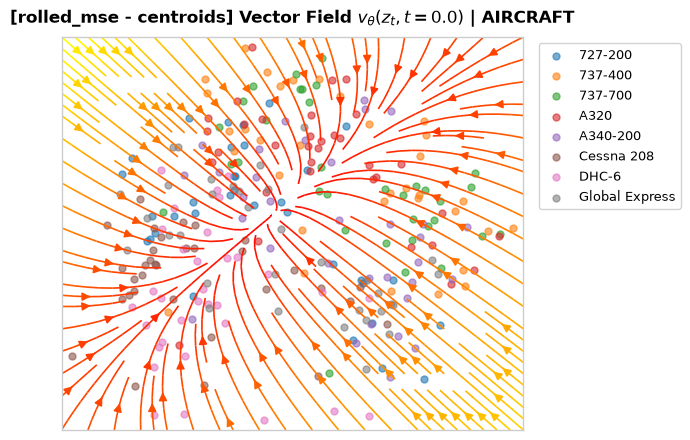

> Plotting Trajectories (k=full, T=4)...


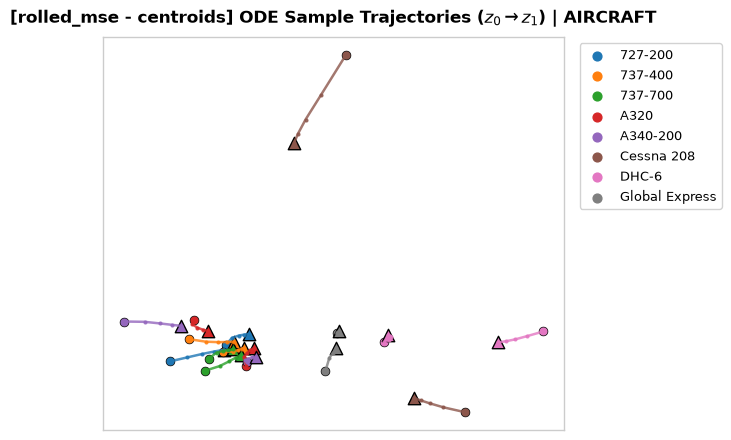

> Plotting Trajectories (k=full, T=12)...


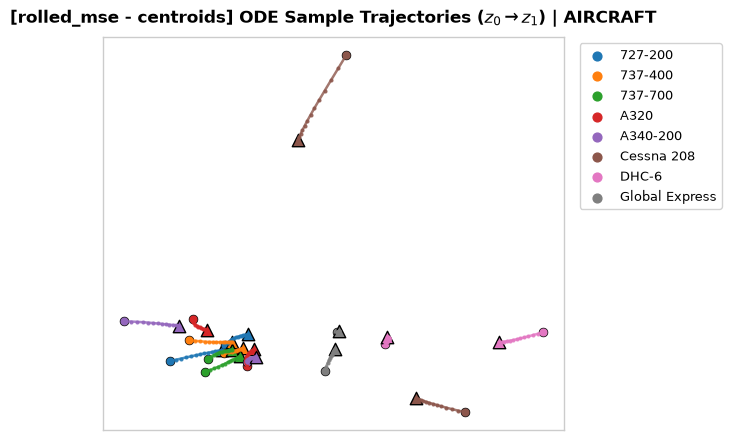


=== CONFIGURATION (Noise 1.0): Objective = ROLLED_MSE   | Target = PROBE_WEIGHTS   | Dataset = AIRCRAFT (resnet18) ===



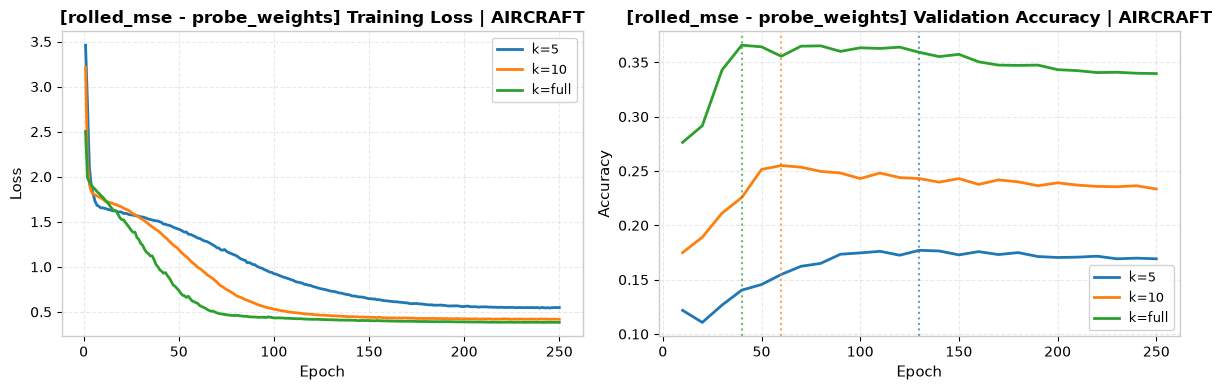


> Plotting 2D Vector Field (k=full)...


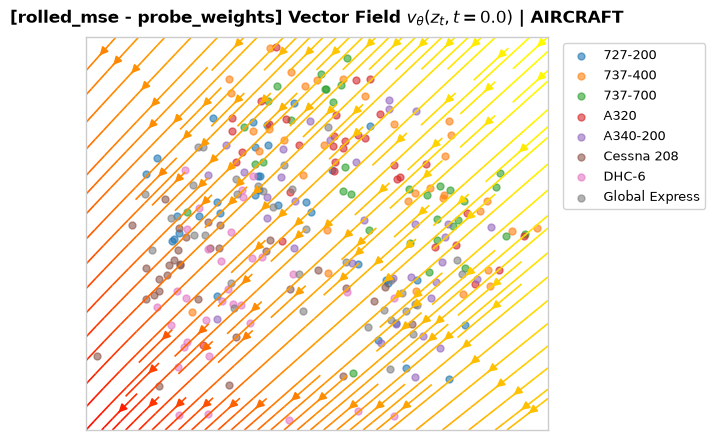

> Plotting Trajectories (k=full, T=4)...


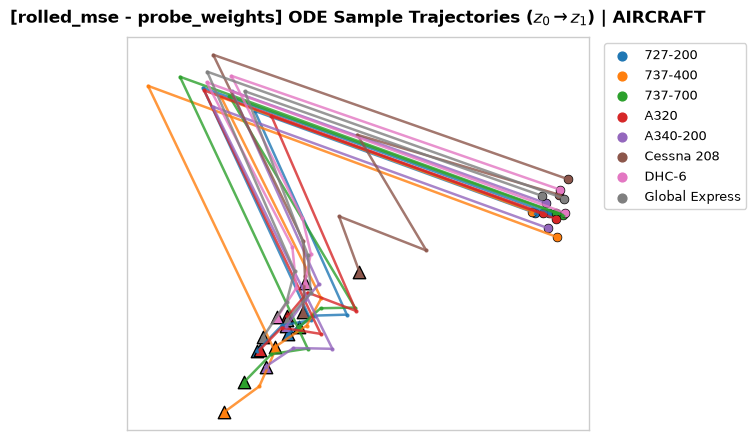

> Plotting Trajectories (k=full, T=12)...


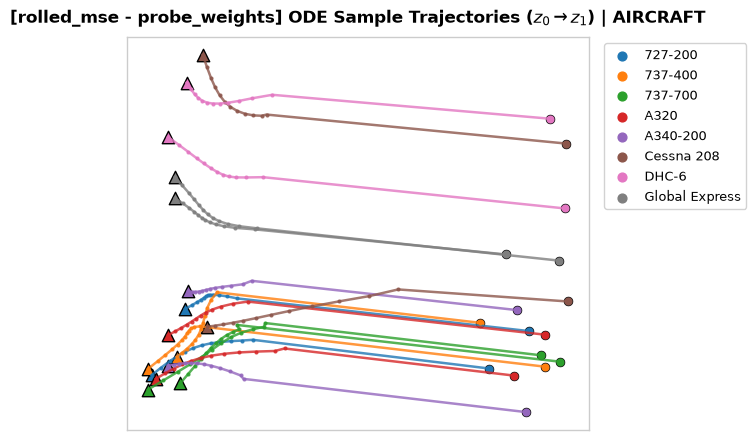

In [12]:
obj = "rolled_mse"
target_seed = 0
target_encoder = "resnet18"
target_dataset = "aircraft"

from src.fmlayer.features.cache import load_split
from src.fmlayer.viz.flow_viz import plot_flow_vector_field_2d, plot_flow_trajectories_2d
from src.fmlayer.train.train_fm import TARGET_TYPES
from src.fmlayer.data.datasets import build_dataset, get_class_names

val_features, val_labels, _ = load_split(target_encoder, target_dataset, "val", FEATURE_ROOT)
val_dataset = build_dataset(target_dataset, "val")
class_names = get_class_names(val_dataset)

for tgt in TARGET_TYPES:
    # Gather history for all K
    histories = {}
    best_epochs = {}
    fm_layer_full = None
    
    for k in [5, 10, "full"]:
        for key, r in fm_results.items():
            if r["encoder"] == target_encoder and r["dataset"] == target_dataset and str(r["k"]) == str(k) and r["seed"] == target_seed and r["objective"] == obj and r["target_type"] == tgt and r.get('target_noise_scale', 0.0) == 1.0:
                histories[k] = r["history"]
                best_epochs[k] = r["best_epoch"]
                if str(k) == "full":
                    fm_layer_full = r["fm_layer"]
                break
    
    if not histories:
        continue
        
    print(f"\n{'='*90}")
    print(f"=== CONFIGURATION (Noise 1.0): Objective = {obj.upper():<12} | Target = {tgt.upper():<15} | Dataset = {target_dataset.upper()} ({target_encoder}) ===")
    print(f"{'='*90}\n")
    
    # 1. Plot Loss
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    colors = {5: '#1f77b4', 10: '#ff7f0e', "full": '#2ca02c'}
    
    for k, history in histories.items():
        epochs = [entry["epoch"] for entry in history]
        train_loss = [entry["train_loss"] for entry in history]
        
        val_epochs = [entry["epoch"] for entry in history if "val_accuracy" in entry]
        val_acc = [entry["val_accuracy"] for entry in history if "val_accuracy" in entry]

        ax1.plot(epochs, train_loss, color=colors[k], linewidth=2, label=f'k={k}')
        
        if len(val_epochs) > 0:
            ax2.plot(val_epochs, val_acc, color=colors[k], linewidth=2, label=f'k={k}')
        if k in best_epochs and best_epochs[k] is not None:
            ax2.axvline(best_epochs[k], color=colors[k], linestyle=':', alpha=0.7)

    ax1.set_title(f"[{obj} - {tgt}] Training Loss | {target_dataset.upper()}")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.grid(alpha=0.3)
    ax1.legend()

    ax2.set_title(f"[{obj} - {tgt}] Validation Accuracy | {target_dataset.upper()}")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.grid(alpha=0.3)
    ax2.legend()
    plt.tight_layout()
    plt.show()
    
    if fm_layer_full is not None:
        metadata = {"dataset": target_dataset, "class_names": class_names, "objective": obj, "target_type": tgt}
        
        # 2. Vector Field
        print("\n> Plotting 2D Vector Field (k=full)...")
        plot_flow_vector_field_2d(
            fm_layer=fm_layer_full,
            features=val_features,
            labels=val_labels,
            metadata=metadata,
            t=0.0
        )
        
        # 3. Flow Trajectories
        print("> Plotting Trajectories (k=full, T=4)...")
        plot_flow_trajectories_2d(
            fm_layer=fm_layer_full,
            features=val_features,
            labels=val_labels,
            metadata=metadata,
            num_steps=4
        )
        
        print("> Plotting Trajectories (k=full, T=12)...")
        plot_flow_trajectories_2d(
            fm_layer=fm_layer_full,
            features=val_features,
            labels=val_labels,
            metadata=metadata,
            num_steps=12
        )


### 5.6 Objective: `ROLLED_MSE` | Dataset: `DTD` (dinov2_vits14)


=== CONFIGURATION (Noise 1.0): Objective = ROLLED_MSE   | Target = CENTROIDS       | Dataset = DTD (dinov2_vits14) ===



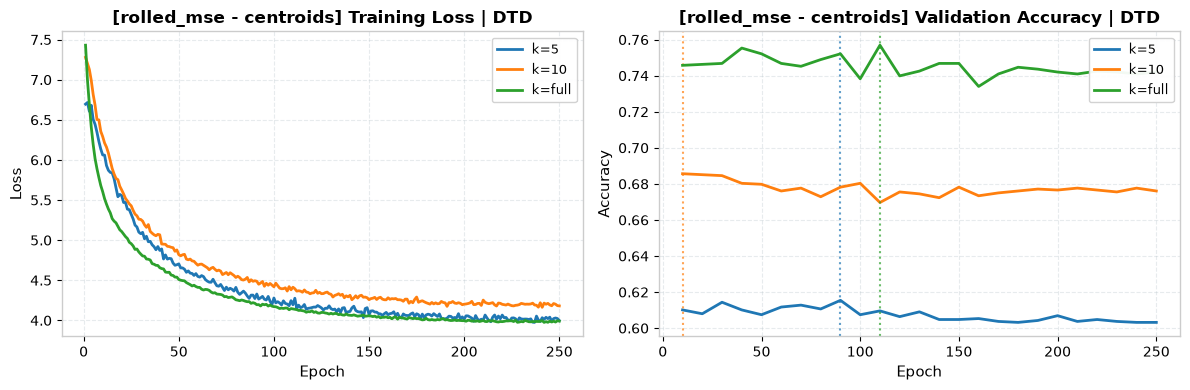


> Plotting 2D Vector Field (k=full)...


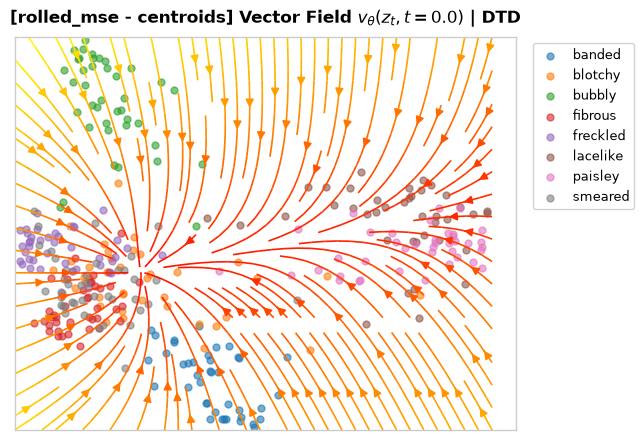

> Plotting Trajectories (k=full, T=4)...


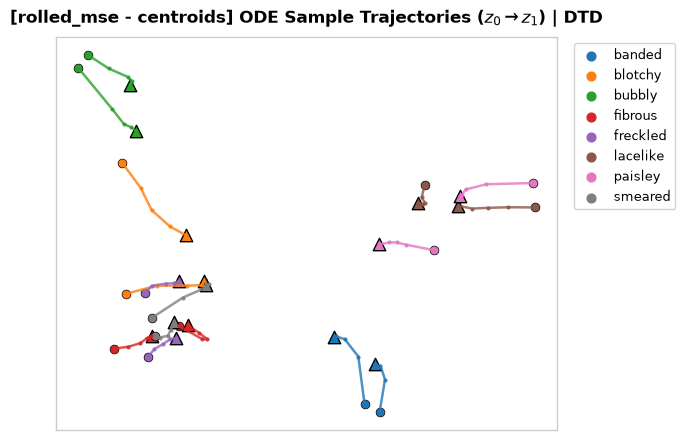

> Plotting Trajectories (k=full, T=12)...


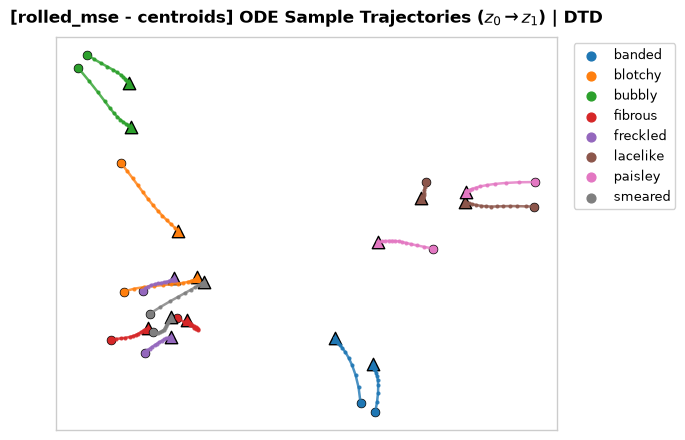


=== CONFIGURATION (Noise 1.0): Objective = ROLLED_MSE   | Target = PROBE_WEIGHTS   | Dataset = DTD (dinov2_vits14) ===



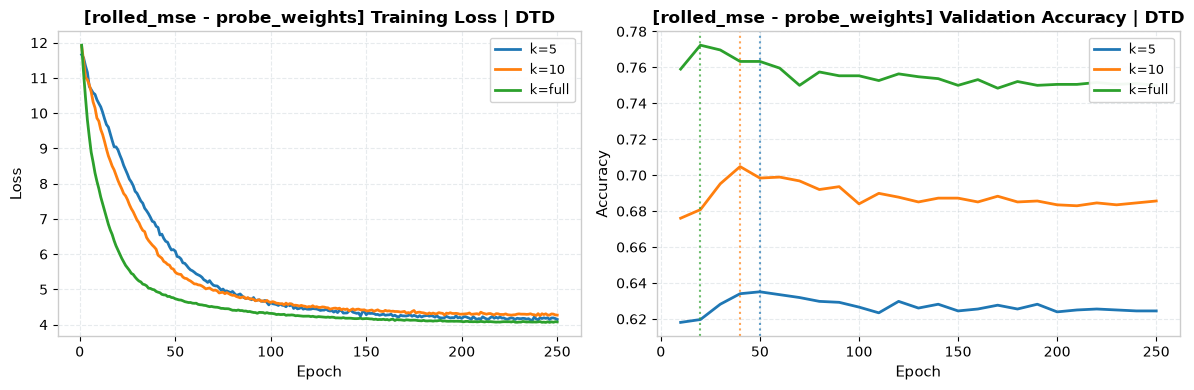


> Plotting 2D Vector Field (k=full)...


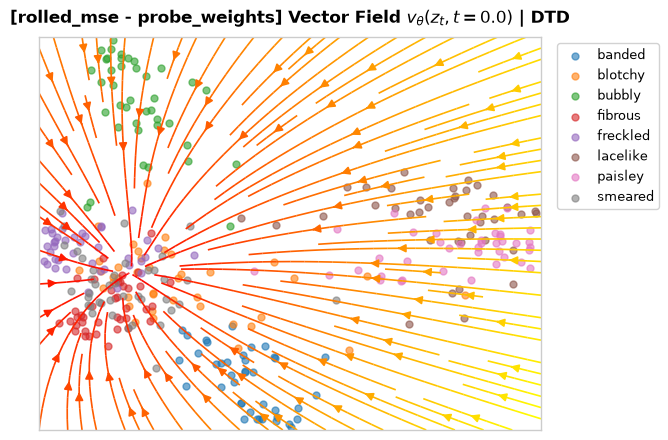

> Plotting Trajectories (k=full, T=4)...


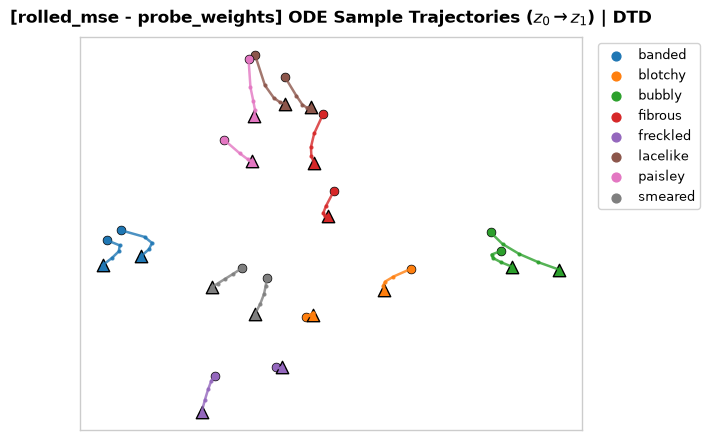

> Plotting Trajectories (k=full, T=12)...


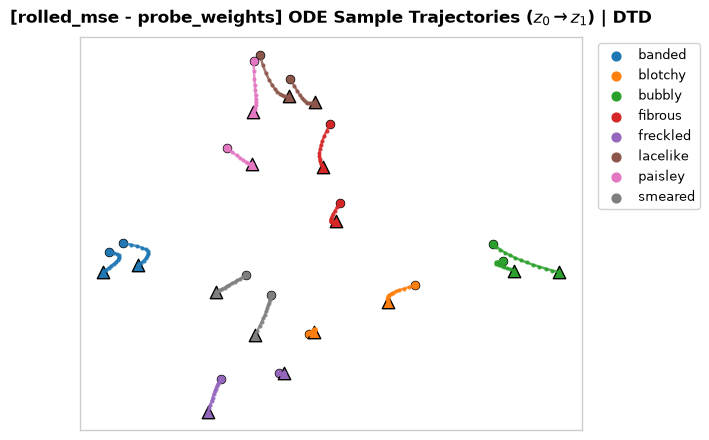

In [13]:
obj = "rolled_mse"
target_seed = 0
target_encoder = "dinov2_vits14"
target_dataset = "dtd"

from src.fmlayer.features.cache import load_split
from src.fmlayer.viz.flow_viz import plot_flow_vector_field_2d, plot_flow_trajectories_2d
from src.fmlayer.train.train_fm import TARGET_TYPES
from src.fmlayer.data.datasets import build_dataset, get_class_names

val_features, val_labels, _ = load_split(target_encoder, target_dataset, "val", FEATURE_ROOT)
val_dataset = build_dataset(target_dataset, "val")
class_names = get_class_names(val_dataset)

for tgt in TARGET_TYPES:
    # Gather history for all K
    histories = {}
    best_epochs = {}
    fm_layer_full = None
    
    for k in [5, 10, "full"]:
        for key, r in fm_results.items():
            if r["encoder"] == target_encoder and r["dataset"] == target_dataset and str(r["k"]) == str(k) and r["seed"] == target_seed and r["objective"] == obj and r["target_type"] == tgt and r.get('target_noise_scale', 0.0) == 1.0:
                histories[k] = r["history"]
                best_epochs[k] = r["best_epoch"]
                if str(k) == "full":
                    fm_layer_full = r["fm_layer"]
                break
    
    if not histories:
        continue
        
    print(f"\n{'='*90}")
    print(f"=== CONFIGURATION (Noise 1.0): Objective = {obj.upper():<12} | Target = {tgt.upper():<15} | Dataset = {target_dataset.upper()} ({target_encoder}) ===")
    print(f"{'='*90}\n")
    
    # 1. Plot Loss
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    colors = {5: '#1f77b4', 10: '#ff7f0e', "full": '#2ca02c'}
    
    for k, history in histories.items():
        epochs = [entry["epoch"] for entry in history]
        train_loss = [entry["train_loss"] for entry in history]
        
        val_epochs = [entry["epoch"] for entry in history if "val_accuracy" in entry]
        val_acc = [entry["val_accuracy"] for entry in history if "val_accuracy" in entry]

        ax1.plot(epochs, train_loss, color=colors[k], linewidth=2, label=f'k={k}')
        
        if len(val_epochs) > 0:
            ax2.plot(val_epochs, val_acc, color=colors[k], linewidth=2, label=f'k={k}')
        if k in best_epochs and best_epochs[k] is not None:
            ax2.axvline(best_epochs[k], color=colors[k], linestyle=':', alpha=0.7)

    ax1.set_title(f"[{obj} - {tgt}] Training Loss | {target_dataset.upper()}")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.grid(alpha=0.3)
    ax1.legend()

    ax2.set_title(f"[{obj} - {tgt}] Validation Accuracy | {target_dataset.upper()}")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.grid(alpha=0.3)
    ax2.legend()
    plt.tight_layout()
    plt.show()
    
    if fm_layer_full is not None:
        metadata = {"dataset": target_dataset, "class_names": class_names, "objective": obj, "target_type": tgt}
        
        # 2. Vector Field
        print("\n> Plotting 2D Vector Field (k=full)...")
        plot_flow_vector_field_2d(
            fm_layer=fm_layer_full,
            features=val_features,
            labels=val_labels,
            metadata=metadata,
            t=0.0
        )
        
        # 3. Flow Trajectories
        print("> Plotting Trajectories (k=full, T=4)...")
        plot_flow_trajectories_2d(
            fm_layer=fm_layer_full,
            features=val_features,
            labels=val_labels,
            metadata=metadata,
            num_steps=4
        )
        
        print("> Plotting Trajectories (k=full, T=12)...")
        plot_flow_trajectories_2d(
            fm_layer=fm_layer_full,
            features=val_features,
            labels=val_labels,
            metadata=metadata,
            num_steps=12
        )


### 5.7 Objective: `ROLLED_CE` | Dataset: `DTD` (resnet18)


=== CONFIGURATION (Noise 1.0): Objective = ROLLED_CE    | Target = CENTROIDS       | Dataset = DTD (resnet18) ===



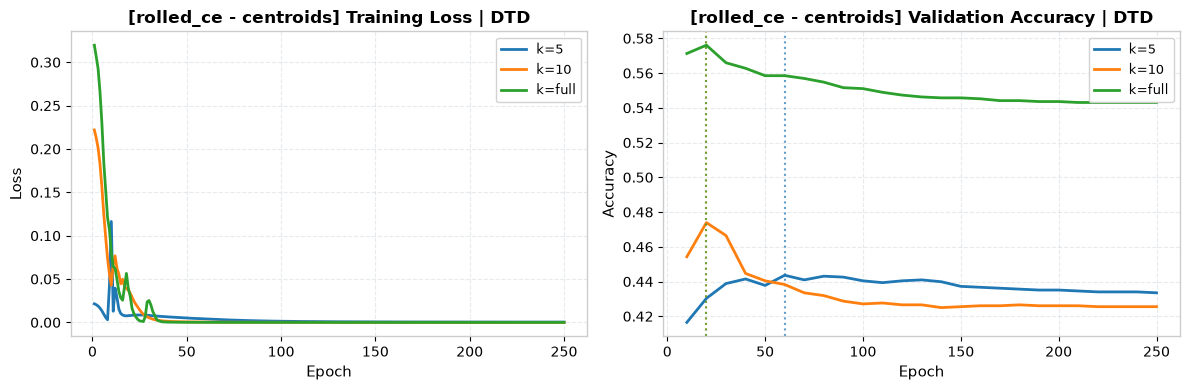


> Plotting 2D Vector Field (k=full)...


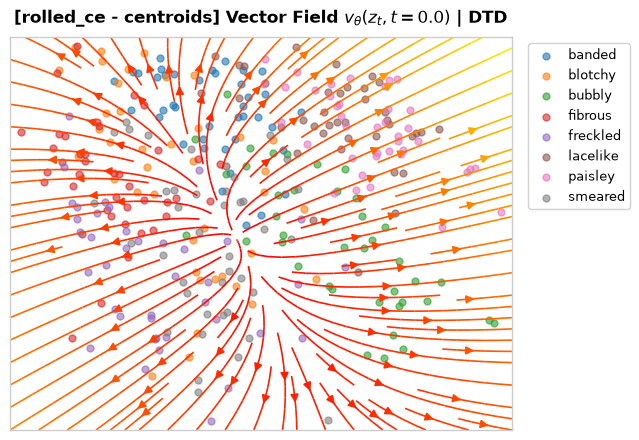

> Plotting Trajectories (k=full, T=4)...


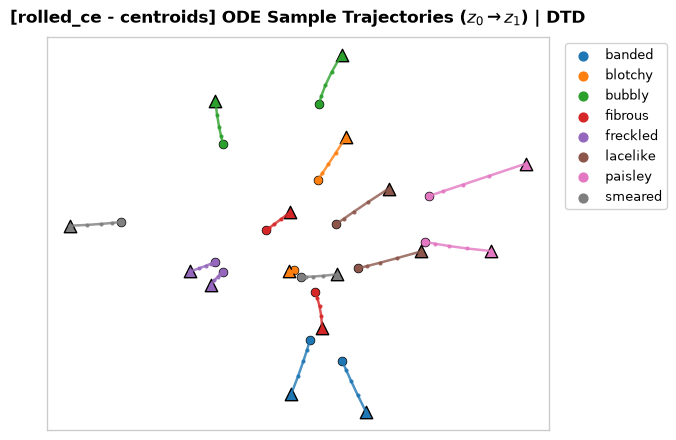

> Plotting Trajectories (k=full, T=12)...


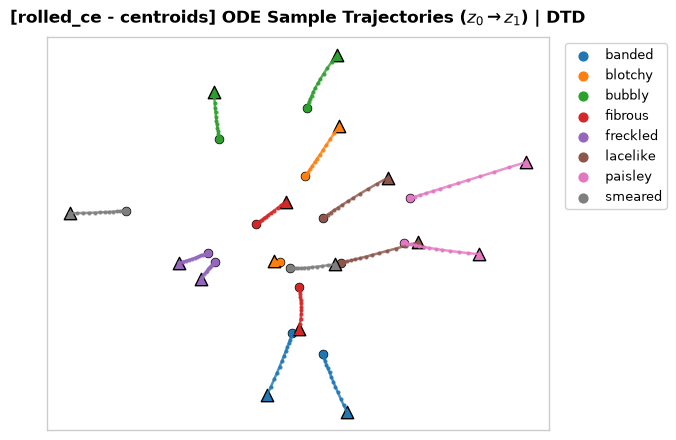


=== CONFIGURATION (Noise 1.0): Objective = ROLLED_CE    | Target = PROBE_WEIGHTS   | Dataset = DTD (resnet18) ===



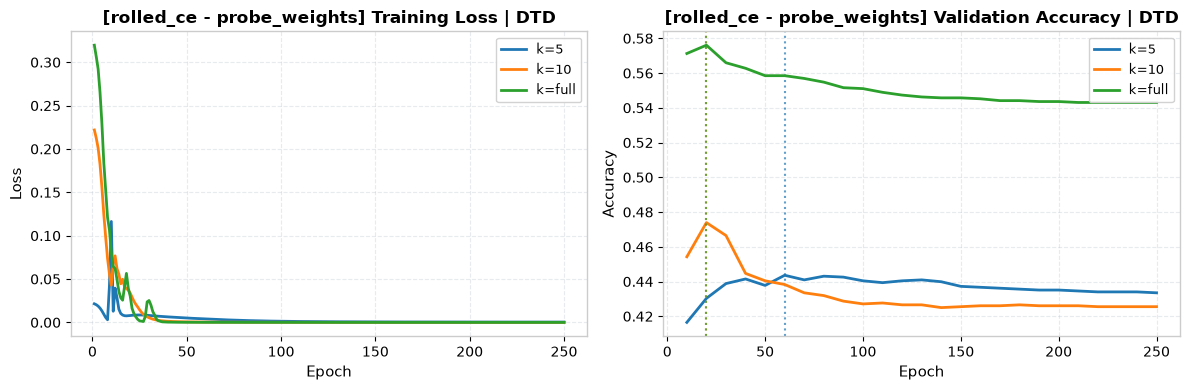


> Plotting 2D Vector Field (k=full)...


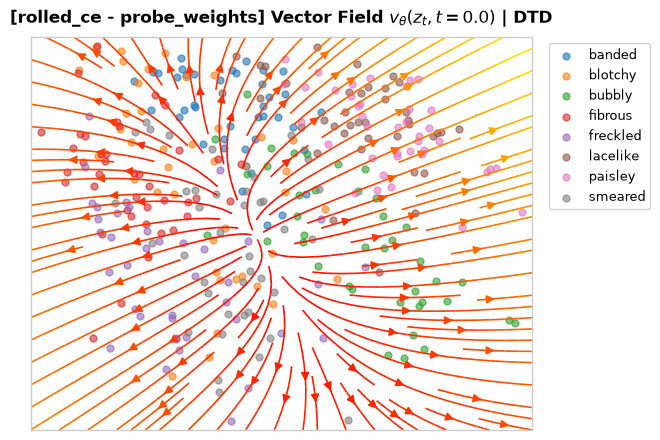

> Plotting Trajectories (k=full, T=4)...


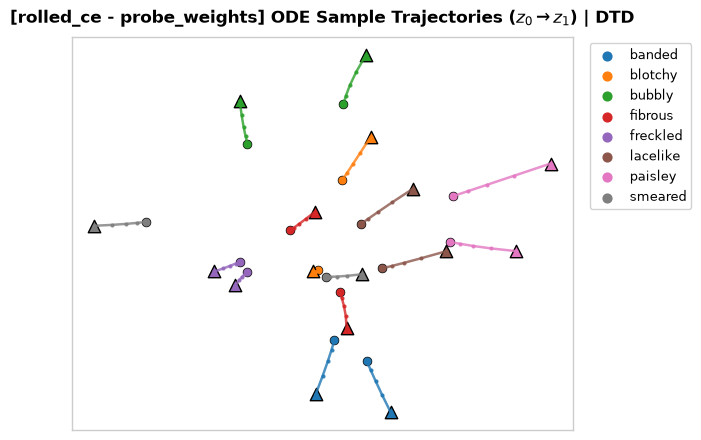

> Plotting Trajectories (k=full, T=12)...


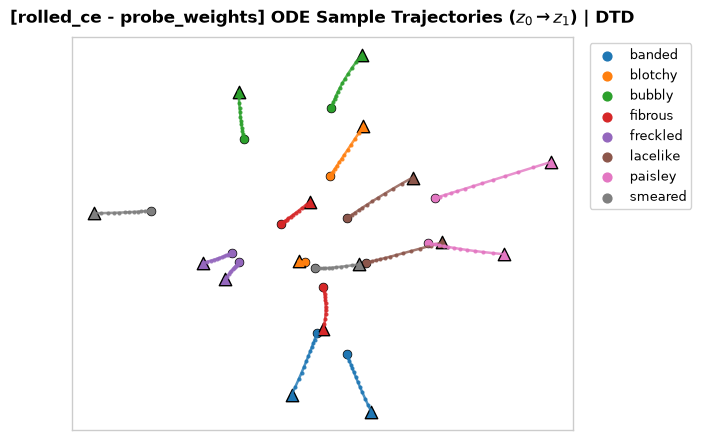

In [14]:
obj = "rolled_ce"
target_seed = 0
target_encoder = "resnet18"
target_dataset = "dtd"

from src.fmlayer.features.cache import load_split
from src.fmlayer.viz.flow_viz import plot_flow_vector_field_2d, plot_flow_trajectories_2d
from src.fmlayer.train.train_fm import TARGET_TYPES
from src.fmlayer.data.datasets import build_dataset, get_class_names

val_features, val_labels, _ = load_split(target_encoder, target_dataset, "val", FEATURE_ROOT)
val_dataset = build_dataset(target_dataset, "val")
class_names = get_class_names(val_dataset)

for tgt in TARGET_TYPES:
    # Gather history for all K
    histories = {}
    best_epochs = {}
    fm_layer_full = None
    
    for k in [5, 10, "full"]:
        for key, r in fm_results.items():
            if r["encoder"] == target_encoder and r["dataset"] == target_dataset and str(r["k"]) == str(k) and r["seed"] == target_seed and r["objective"] == obj and r["target_type"] == tgt and r.get('target_noise_scale', 0.0) == 1.0:
                histories[k] = r["history"]
                best_epochs[k] = r["best_epoch"]
                if str(k) == "full":
                    fm_layer_full = r["fm_layer"]
                break
    
    if not histories:
        continue
        
    print(f"\n{'='*90}")
    print(f"=== CONFIGURATION (Noise 1.0): Objective = {obj.upper():<12} | Target = {tgt.upper():<15} | Dataset = {target_dataset.upper()} ({target_encoder}) ===")
    print(f"{'='*90}\n")
    
    # 1. Plot Loss
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    colors = {5: '#1f77b4', 10: '#ff7f0e', "full": '#2ca02c'}
    
    for k, history in histories.items():
        epochs = [entry["epoch"] for entry in history]
        train_loss = [entry["train_loss"] for entry in history]
        
        val_epochs = [entry["epoch"] for entry in history if "val_accuracy" in entry]
        val_acc = [entry["val_accuracy"] for entry in history if "val_accuracy" in entry]

        ax1.plot(epochs, train_loss, color=colors[k], linewidth=2, label=f'k={k}')
        
        if len(val_epochs) > 0:
            ax2.plot(val_epochs, val_acc, color=colors[k], linewidth=2, label=f'k={k}')
        if k in best_epochs and best_epochs[k] is not None:
            ax2.axvline(best_epochs[k], color=colors[k], linestyle=':', alpha=0.7)

    ax1.set_title(f"[{obj} - {tgt}] Training Loss | {target_dataset.upper()}")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.grid(alpha=0.3)
    ax1.legend()

    ax2.set_title(f"[{obj} - {tgt}] Validation Accuracy | {target_dataset.upper()}")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.grid(alpha=0.3)
    ax2.legend()
    plt.tight_layout()
    plt.show()
    
    if fm_layer_full is not None:
        metadata = {"dataset": target_dataset, "class_names": class_names, "objective": obj, "target_type": tgt}
        
        # 2. Vector Field
        print("\n> Plotting 2D Vector Field (k=full)...")
        plot_flow_vector_field_2d(
            fm_layer=fm_layer_full,
            features=val_features,
            labels=val_labels,
            metadata=metadata,
            t=0.0
        )
        
        # 3. Flow Trajectories
        print("> Plotting Trajectories (k=full, T=4)...")
        plot_flow_trajectories_2d(
            fm_layer=fm_layer_full,
            features=val_features,
            labels=val_labels,
            metadata=metadata,
            num_steps=4
        )
        
        print("> Plotting Trajectories (k=full, T=12)...")
        plot_flow_trajectories_2d(
            fm_layer=fm_layer_full,
            features=val_features,
            labels=val_labels,
            metadata=metadata,
            num_steps=12
        )


### 5.8 Objective: `ROLLED_CE` | Dataset: `AIRCRAFT` (resnet18)


=== CONFIGURATION (Noise 1.0): Objective = ROLLED_CE    | Target = CENTROIDS       | Dataset = AIRCRAFT (resnet18) ===



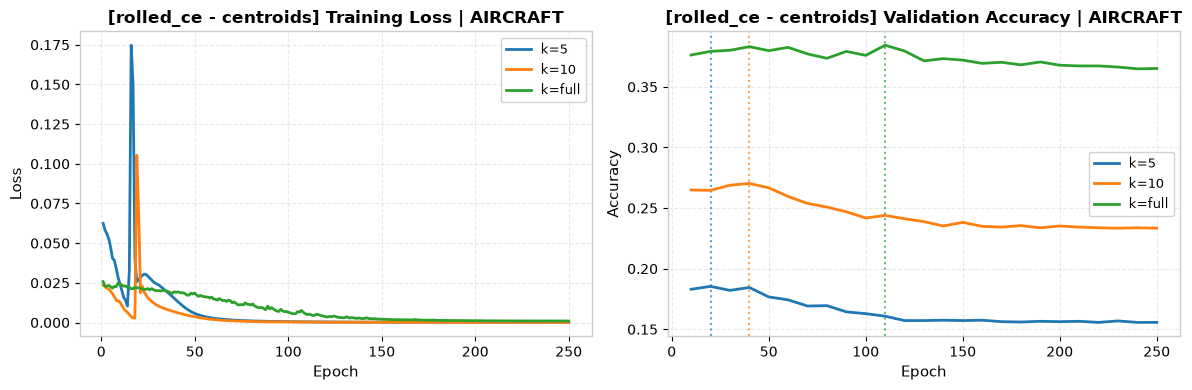


> Plotting 2D Vector Field (k=full)...


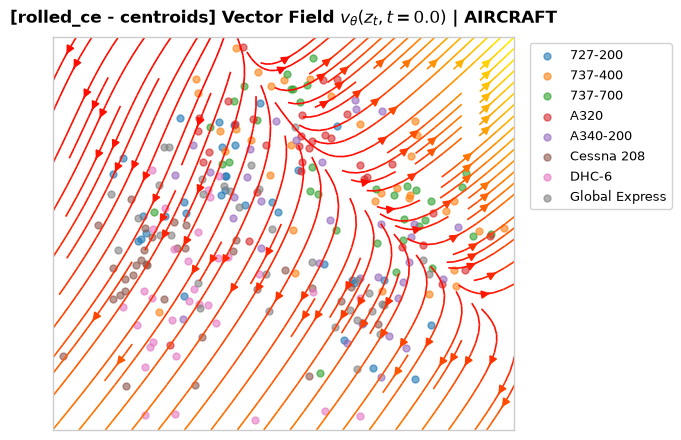

> Plotting Trajectories (k=full, T=4)...


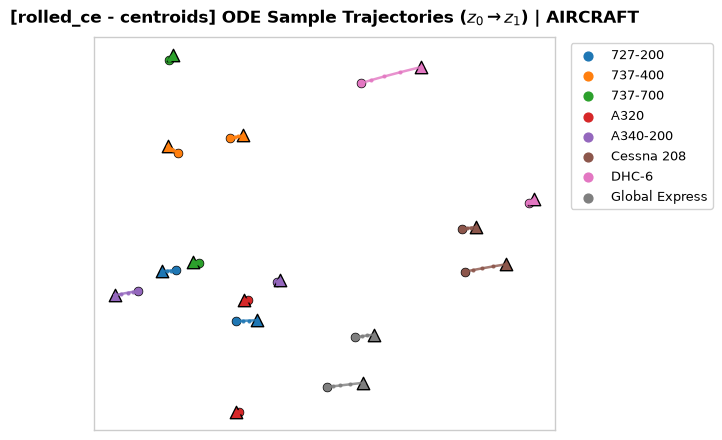

> Plotting Trajectories (k=full, T=12)...


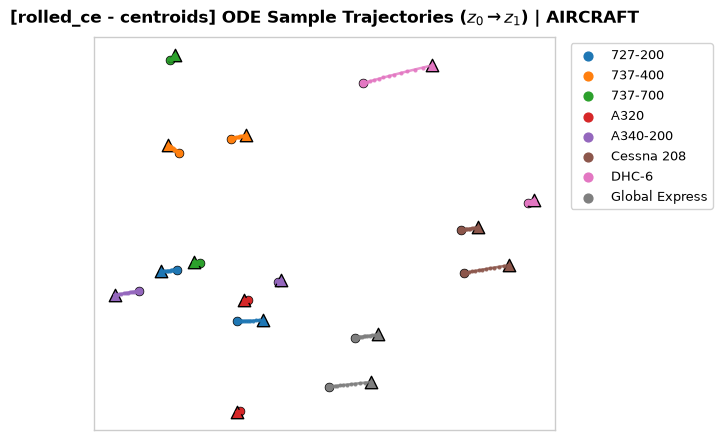


=== CONFIGURATION (Noise 1.0): Objective = ROLLED_CE    | Target = PROBE_WEIGHTS   | Dataset = AIRCRAFT (resnet18) ===



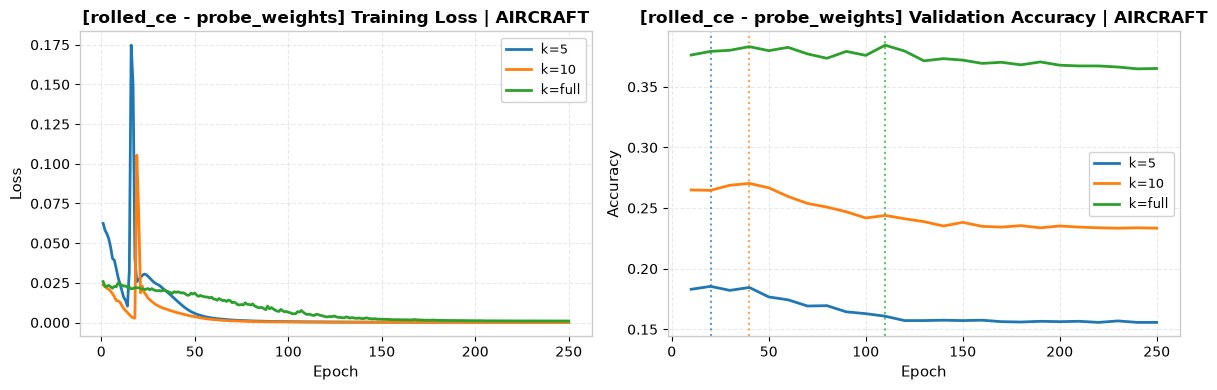


> Plotting 2D Vector Field (k=full)...


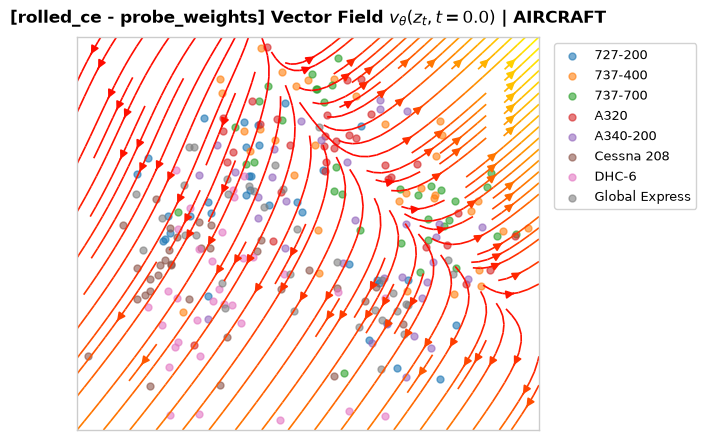

> Plotting Trajectories (k=full, T=4)...


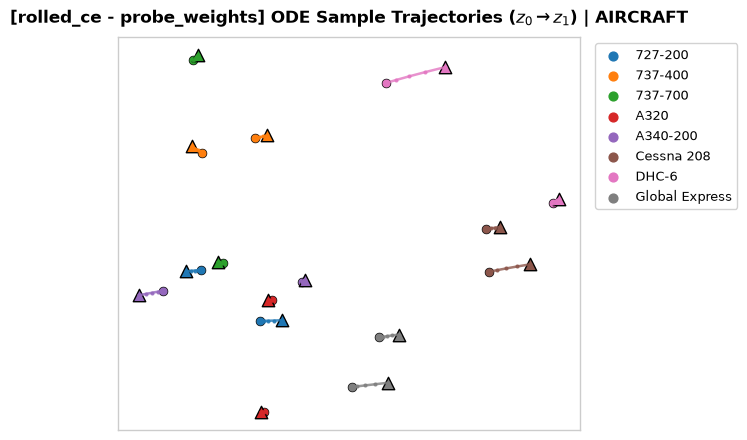

> Plotting Trajectories (k=full, T=12)...


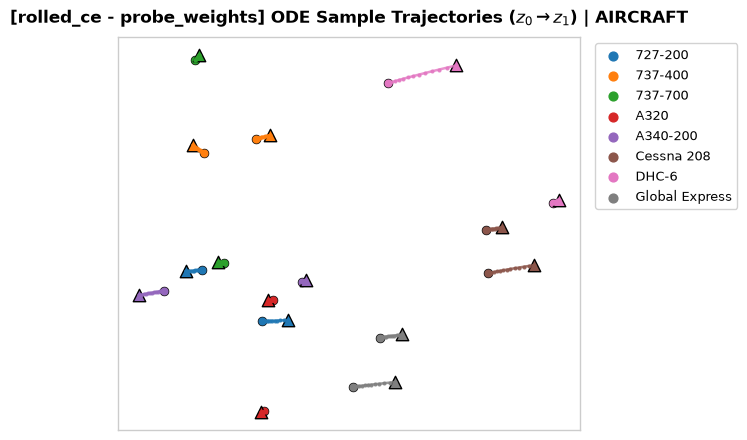

In [15]:
obj = "rolled_ce"
target_seed = 0
target_encoder = "resnet18"
target_dataset = "aircraft"

from src.fmlayer.features.cache import load_split
from src.fmlayer.viz.flow_viz import plot_flow_vector_field_2d, plot_flow_trajectories_2d
from src.fmlayer.train.train_fm import TARGET_TYPES
from src.fmlayer.data.datasets import build_dataset, get_class_names

val_features, val_labels, _ = load_split(target_encoder, target_dataset, "val", FEATURE_ROOT)
val_dataset = build_dataset(target_dataset, "val")
class_names = get_class_names(val_dataset)

for tgt in TARGET_TYPES:
    # Gather history for all K
    histories = {}
    best_epochs = {}
    fm_layer_full = None
    
    for k in [5, 10, "full"]:
        for key, r in fm_results.items():
            if r["encoder"] == target_encoder and r["dataset"] == target_dataset and str(r["k"]) == str(k) and r["seed"] == target_seed and r["objective"] == obj and r["target_type"] == tgt and r.get('target_noise_scale', 0.0) == 1.0:
                histories[k] = r["history"]
                best_epochs[k] = r["best_epoch"]
                if str(k) == "full":
                    fm_layer_full = r["fm_layer"]
                break
    
    if not histories:
        continue
        
    print(f"\n{'='*90}")
    print(f"=== CONFIGURATION (Noise 1.0): Objective = {obj.upper():<12} | Target = {tgt.upper():<15} | Dataset = {target_dataset.upper()} ({target_encoder}) ===")
    print(f"{'='*90}\n")
    
    # 1. Plot Loss
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    colors = {5: '#1f77b4', 10: '#ff7f0e', "full": '#2ca02c'}
    
    for k, history in histories.items():
        epochs = [entry["epoch"] for entry in history]
        train_loss = [entry["train_loss"] for entry in history]
        
        val_epochs = [entry["epoch"] for entry in history if "val_accuracy" in entry]
        val_acc = [entry["val_accuracy"] for entry in history if "val_accuracy" in entry]

        ax1.plot(epochs, train_loss, color=colors[k], linewidth=2, label=f'k={k}')
        
        if len(val_epochs) > 0:
            ax2.plot(val_epochs, val_acc, color=colors[k], linewidth=2, label=f'k={k}')
        if k in best_epochs and best_epochs[k] is not None:
            ax2.axvline(best_epochs[k], color=colors[k], linestyle=':', alpha=0.7)

    ax1.set_title(f"[{obj} - {tgt}] Training Loss | {target_dataset.upper()}")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.grid(alpha=0.3)
    ax1.legend()

    ax2.set_title(f"[{obj} - {tgt}] Validation Accuracy | {target_dataset.upper()}")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.grid(alpha=0.3)
    ax2.legend()
    plt.tight_layout()
    plt.show()
    
    if fm_layer_full is not None:
        metadata = {"dataset": target_dataset, "class_names": class_names, "objective": obj, "target_type": tgt}
        
        # 2. Vector Field
        print("\n> Plotting 2D Vector Field (k=full)...")
        plot_flow_vector_field_2d(
            fm_layer=fm_layer_full,
            features=val_features,
            labels=val_labels,
            metadata=metadata,
            t=0.0
        )
        
        # 3. Flow Trajectories
        print("> Plotting Trajectories (k=full, T=4)...")
        plot_flow_trajectories_2d(
            fm_layer=fm_layer_full,
            features=val_features,
            labels=val_labels,
            metadata=metadata,
            num_steps=4
        )
        
        print("> Plotting Trajectories (k=full, T=12)...")
        plot_flow_trajectories_2d(
            fm_layer=fm_layer_full,
            features=val_features,
            labels=val_labels,
            metadata=metadata,
            num_steps=12
        )


### 5.9 Objective: `ROLLED_CE` | Dataset: `DTD` (dinov2_vits14)


=== CONFIGURATION (Noise 1.0): Objective = ROLLED_CE    | Target = CENTROIDS       | Dataset = DTD (dinov2_vits14) ===



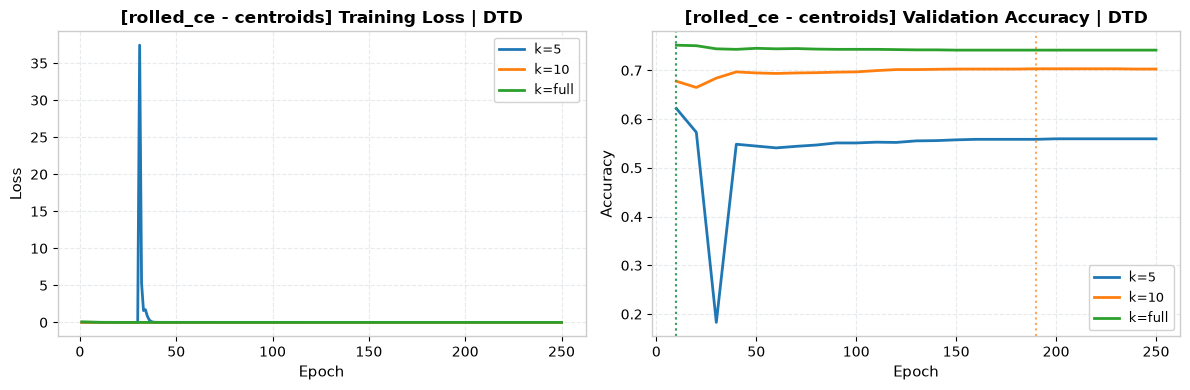


> Plotting 2D Vector Field (k=full)...


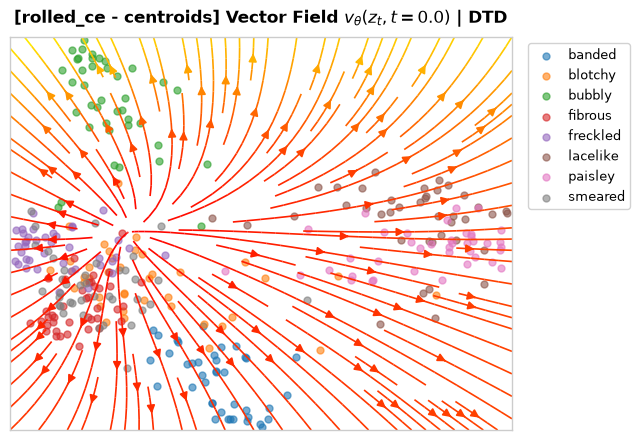

> Plotting Trajectories (k=full, T=4)...


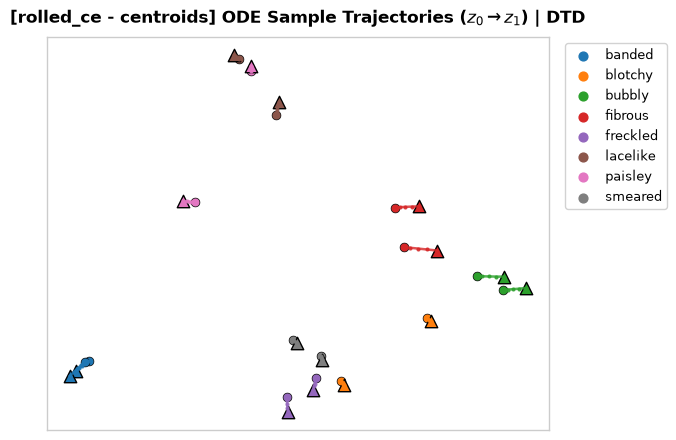

> Plotting Trajectories (k=full, T=12)...


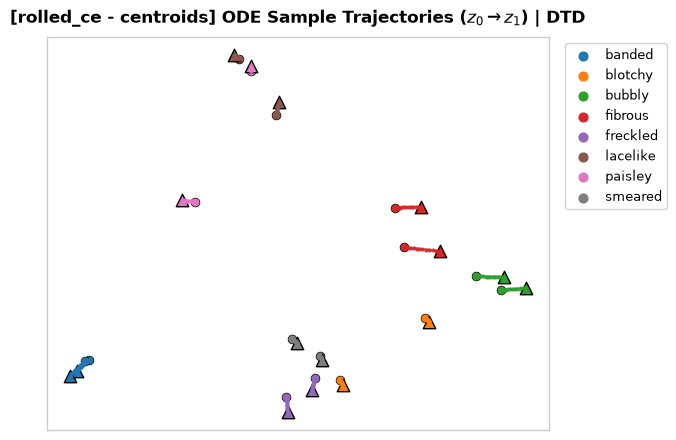


=== CONFIGURATION (Noise 1.0): Objective = ROLLED_CE    | Target = PROBE_WEIGHTS   | Dataset = DTD (dinov2_vits14) ===



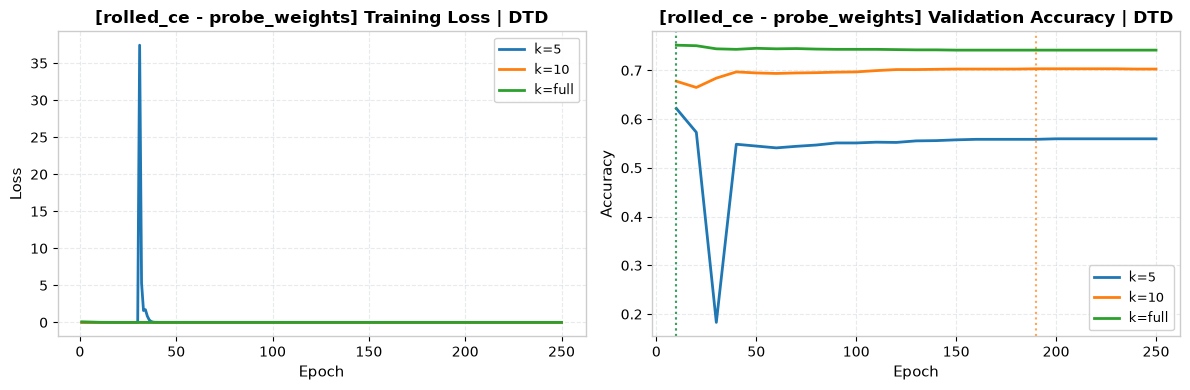


> Plotting 2D Vector Field (k=full)...


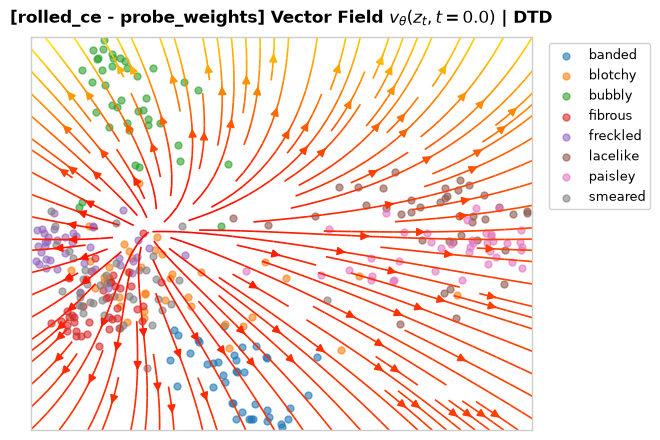

> Plotting Trajectories (k=full, T=4)...


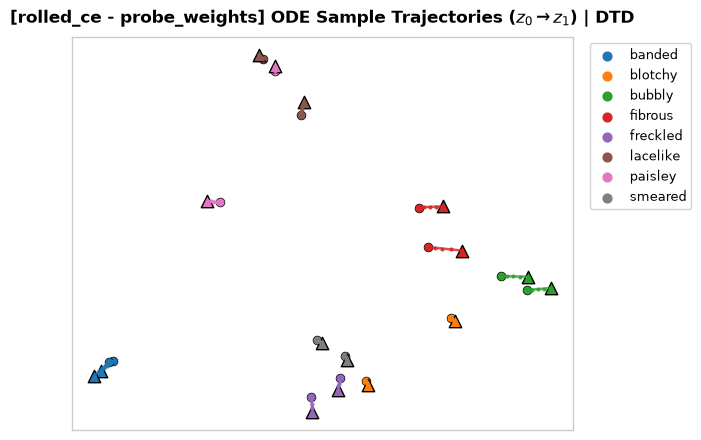

> Plotting Trajectories (k=full, T=12)...


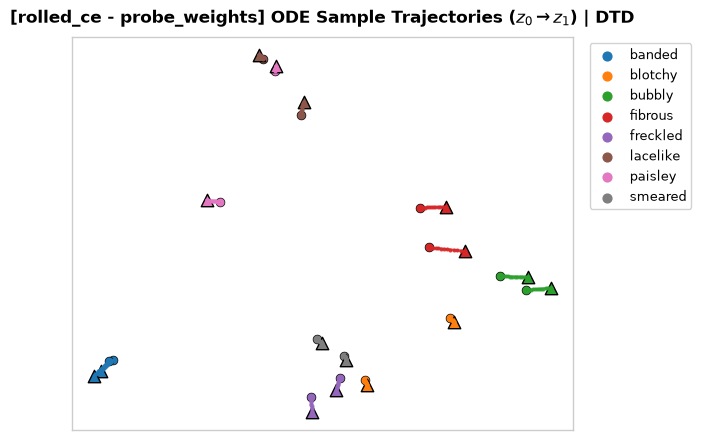

In [16]:
obj = "rolled_ce"
target_seed = 0
target_encoder = "dinov2_vits14"
target_dataset = "dtd"

from src.fmlayer.features.cache import load_split
from src.fmlayer.viz.flow_viz import plot_flow_vector_field_2d, plot_flow_trajectories_2d
from src.fmlayer.train.train_fm import TARGET_TYPES
from src.fmlayer.data.datasets import build_dataset, get_class_names

val_features, val_labels, _ = load_split(target_encoder, target_dataset, "val", FEATURE_ROOT)
val_dataset = build_dataset(target_dataset, "val")
class_names = get_class_names(val_dataset)

for tgt in TARGET_TYPES:
    # Gather history for all K
    histories = {}
    best_epochs = {}
    fm_layer_full = None
    
    for k in [5, 10, "full"]:
        for key, r in fm_results.items():
            if r["encoder"] == target_encoder and r["dataset"] == target_dataset and str(r["k"]) == str(k) and r["seed"] == target_seed and r["objective"] == obj and r["target_type"] == tgt and r.get('target_noise_scale', 0.0) == 1.0:
                histories[k] = r["history"]
                best_epochs[k] = r["best_epoch"]
                if str(k) == "full":
                    fm_layer_full = r["fm_layer"]
                break
    
    if not histories:
        continue
        
    print(f"\n{'='*90}")
    print(f"=== CONFIGURATION (Noise 1.0): Objective = {obj.upper():<12} | Target = {tgt.upper():<15} | Dataset = {target_dataset.upper()} ({target_encoder}) ===")
    print(f"{'='*90}\n")
    
    # 1. Plot Loss
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    colors = {5: '#1f77b4', 10: '#ff7f0e', "full": '#2ca02c'}
    
    for k, history in histories.items():
        epochs = [entry["epoch"] for entry in history]
        train_loss = [entry["train_loss"] for entry in history]
        
        val_epochs = [entry["epoch"] for entry in history if "val_accuracy" in entry]
        val_acc = [entry["val_accuracy"] for entry in history if "val_accuracy" in entry]

        ax1.plot(epochs, train_loss, color=colors[k], linewidth=2, label=f'k={k}')
        
        if len(val_epochs) > 0:
            ax2.plot(val_epochs, val_acc, color=colors[k], linewidth=2, label=f'k={k}')
        if k in best_epochs and best_epochs[k] is not None:
            ax2.axvline(best_epochs[k], color=colors[k], linestyle=':', alpha=0.7)

    ax1.set_title(f"[{obj} - {tgt}] Training Loss | {target_dataset.upper()}")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.grid(alpha=0.3)
    ax1.legend()

    ax2.set_title(f"[{obj} - {tgt}] Validation Accuracy | {target_dataset.upper()}")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.grid(alpha=0.3)
    ax2.legend()
    plt.tight_layout()
    plt.show()
    
    if fm_layer_full is not None:
        metadata = {"dataset": target_dataset, "class_names": class_names, "objective": obj, "target_type": tgt}
        
        # 2. Vector Field
        print("\n> Plotting 2D Vector Field (k=full)...")
        plot_flow_vector_field_2d(
            fm_layer=fm_layer_full,
            features=val_features,
            labels=val_labels,
            metadata=metadata,
            t=0.0
        )
        
        # 3. Flow Trajectories
        print("> Plotting Trajectories (k=full, T=4)...")
        plot_flow_trajectories_2d(
            fm_layer=fm_layer_full,
            features=val_features,
            labels=val_labels,
            metadata=metadata,
            num_steps=4
        )
        
        print("> Plotting Trajectories (k=full, T=12)...")
        plot_flow_trajectories_2d(
            fm_layer=fm_layer_full,
            features=val_features,
            labels=val_labels,
            metadata=metadata,
            num_steps=12
        )
